# **Bank Telemarketing Dataset -- EDA Approach**

import sys
sys.path.append("..")

import src.my_library as my_library
import src.my_file as my_file
import src.new_file as new_file

In [1]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

## Display Setting

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [4]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
tele_df.shape

(41188, 21)

In [6]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [8]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


### **Brief description of Columns:**

**Bank Client Data Description:**

- **age**: Age of the client (numeric)
- **job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **marital**: Marital status (categorical: 'divorced', 'married', 'single', 'unknown')
- **education**: Level of education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- **default**: Whether the client has credit in default (binary: 'no', 'yes', 'unknown')
- **housing**: Whether the client has a housing loan (binary: 'no', 'yes', 'unknown')
- **loan**: Whether the client has a personal loan (binary: 'no', 'yes', 'unknown')

**Last Contact Data Description:**

- **contact**: Type of communication used to contact the client (categorical: 'cellular', 'telephone')
- **month**: Last contact month of the year (categorical: 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec')
- **day_of_week**: Last contact day of the week (categorical: 'mon', 'tue', 'wed', 'thu', 'fri')
- **duration**: Duration of the last contact in seconds (numeric)
Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model

**Campaign Data Description:**

- **campaign**: Number of contacts performed during this campaign for this client (numeric, includes last contact)
- **pdays**: Number of days since the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
- **previous**: Number of contacts performed before this campaign for this client (numeric) 
- **poutcome**: Outcome of the previous marketing campaign (categorical: 'failure', 'nonexistent', 'success')

**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
- **cons.price.idx**: Consumer price index - monthly indicator (numeric)
- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)
- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


***Dataset Summary:***

**This dataset represents the direct marketing campaign(phone calls) of a Portuguese banking institution, where each record represents a client and the outcome of a marketing campaign to convince the client to subscribe a term deposit. The dataset contains both categorical and numerical features describing each client's demographics, behaviroal, social and economic context, with a binary target variable indicating whether the client subscribed to a term deposit. The data spans from May 2008 to November 2010**

## **Formatting and Consistency Check**

In [9]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


In [10]:
# For numerical columns
def highlight_neg_zero(val):
    if pd.isna(val):
        return "background-color: gray; color: white"
    elif val == 0:
        return "color: k; background-color: yellow"
    elif val < 0:
        return "color: k; background-color: red"
    else:
        return ""


desc_df = tele_df.describe()
style_df = desc_df.style.applymap(highlight_neg_zero)
style_df

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.024060,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.421250,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Investigate:**
- **duration** contains 0 values which is not possible as it is the call duration in seconds.
- **pdays** contains 0.
- **previous** contains 0 value.
- **emp_var_rate** and **cons_conf_idx** contains negative values.


In [11]:
# highlight repeated values in numeric values
def highlight_repeats(ser):
    is_duplicated = ser.duplicated(keep=False)
    return ['background-color: orange' if v else '' for v in is_duplicated]

display(desc_df.style.apply(highlight_repeats))


,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.024060,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.421250,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [12]:
from datetime import datetime as dt
months = list(tele_df['month'].unique())
month_numbers = [dt.strptime(i, "%b").month for i in months]
month_dict = dict(zip(months, month_numbers))
tele_df['month_num'] = tele_df['month'].map(month_dict)
# Sanity check
tele_df[['month', 'month_num']].head()


,month,month_num
0,may,5
1,may,5
2,may,5
3,may,5
4,may,5


It would be more useful to investigate the impact of age for different age groups rather than a continuous variable. We define a new column that categorizes age into 6 different groups.


In [13]:
tele_df['age_groups'] = pd.qcut(tele_df['age'], q=6)


We will divide our clients into new and old groups using the value of pdays.


In [14]:

tele_df['old_new'] = tele_df['pdays'].apply(lambda x: 'old' if x!=999 else 'new')
tele_df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,month_num,age_groups,old_new
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,"(51.0, 98.0]",new
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,"(51.0, 98.0]",new
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,"(34.0, 38.0]",new
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,"(38.0, 44.0]",new
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,5,"(51.0, 98.0]",new


tele_df['date'] = tele_df[['year','month_num','day']].apply(
    lambda row: dt.strptime(
        '-'.join(row.values.astype(str)),
        '%Y-%m-%d'
    ), axis=1
)

# Obtain 'weekday' from 'date' using datetime.strftime
tele_df['weekday'] = tele_df['date'].apply(lambda date: dt.strftime(date, '%A'))
tele_df['weekday'].head()


# **Exploratory Data Analysis**

**Target Variable**

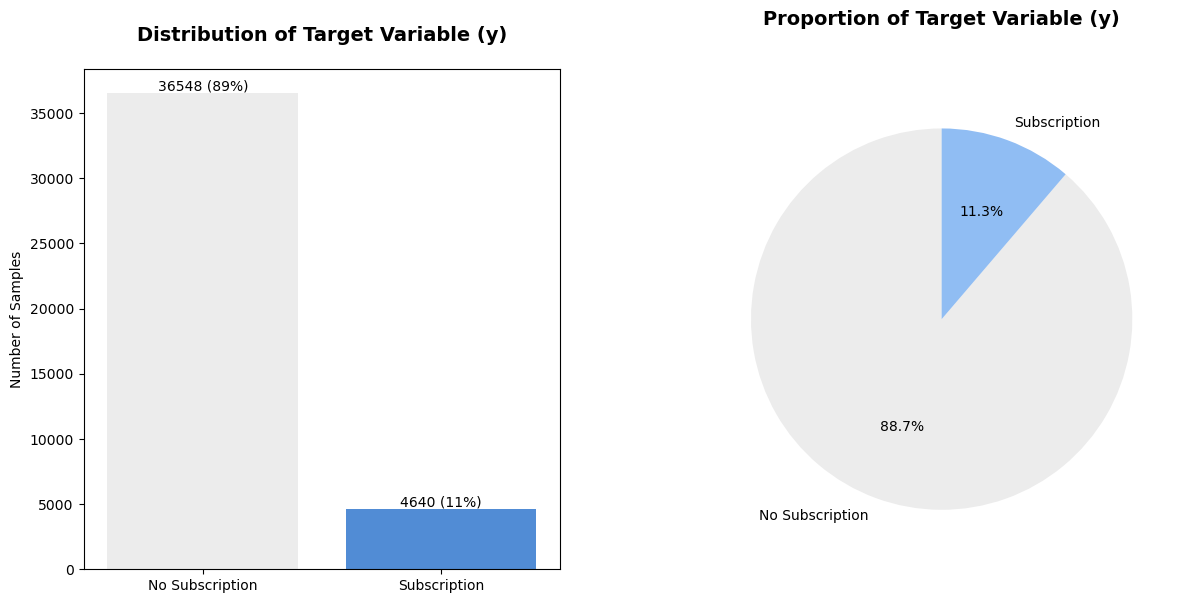

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [16]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

## **Correlation Matrix**

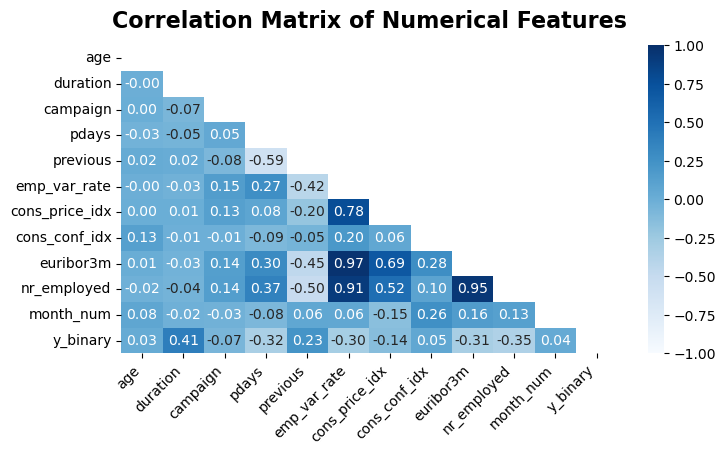

Features with strong correlation to target variable 'y_binary': 

|    | feature      |   corr with y |
|----|--------------|---------------|
|  0 | duration     |          0.41 |
|  1 | emp_var_rate |         -0.3  |
|  2 | euribor3m    |         -0.31 |
|  3 | pdays        |         -0.32 |
|  4 | nr_employed  |         -0.35 |


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
corr_df = tele_df.select_dtypes(include='number').corr(method='pearson')
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', y=1.03)
plt.show()

y_df = corr_df[((corr_df['y_binary'] != 1) & (corr_df['y_binary'] > 0.25)) | (corr_df['y_binary'] < -0.25)][['y_binary']].sort_values(by = 'y_binary',ascending=False)
y_df = y_df.reset_index().rename(columns={'index':'feature', 'y_binary':'corr with y'}).round(2)
print("Features with strong correlation to target variable 'y_binary':", '\n')
print(y_df.to_markdown(tablefmt="github"))

### **Dimension Analysis**

#### **Categorical Dimensions**

**What to do:**

1. Will use some of user defined functions to analyze the dimensions.

**How to do:**
    
- Will compute total number of customers contacted and % of customers who subscribed to a term deposit to describe univariate analysis and do bar plot.
- Will compute total number of customers contacted and % of customers who subscribed to a term deposit to describe bivariate analysi and do heatmap plot.

2. Will start with seasonal dimensions i.e., month, day_of_week, etc.

### **User Defined Functions : Univariate and Bivariate Analysis**

In [18]:
# Reorder months as per natural order
months = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
tele_df['months_order'] = pd.Categorical(tele_df['month'], categories=months, ordered=True)


In [19]:
# Univariate analysis function for categorical variables with bar plots
def univariate_analysis_categorical_var(df, categorical_var, display_name):
    """Compute total count of customers contacted and percentage of customers who subscribed to a term deposit."""
    # Count of campaign for each category
    total_counts = df.groupby([categorical_var])['y'].value_counts().unstack().fillna(0)   
    total_counts['total'] = total_counts.sum(axis='columns')
    total_counts['conversion_rate'] = (total_counts['yes'] / total_counts['total']).round(2)

    fig, ax = plt.subplots(2, 1, sharex=True,figsize=(15, 8), dpi=100)
    #colors = plt.cm.Blues_r(np.arange(0.3, 0.9, len(total_counts.index))) 
    colors = [(0.3, 0.8, 1), (0.6, 0.6, 1), '#0000FF']
    # plot for total campaigns
    x_pos = range(len(total_counts.index))
    ax[0].bar(x_pos, total_counts['total'], color=colors)
    ax[0].set_xticks(x_pos)
    ax[0].set_xticklabels(total_counts.index)
    ax[0].set_ylabel('Count')
    ax[0].set_title(display_name + ' Distribution', fontsize=14, fontweight='bold', y=1.04)
    for i, v in enumerate(total_counts['total']):
        ax[0].text(i, v + 200, f"{int(v)} ({(v/(total_counts['total'].sum(axis=0))):.0%})", ha='center', fontsize=10)

    # plot for successful subscriptions
    ax[1].bar(x_pos, total_counts['conversion_rate'], color=colors)
    ax[1].set_xticks(x_pos)
    ax[1].set_xticklabels(total_counts.index)
    ax[1].set_ylabel('Proportion')
    ax[1].set_title(display_name +" " + 'YES-proportion', fontsize=14, fontweight='bold', y=1.04)
    for i, v in enumerate(total_counts['conversion_rate']):
        ax[1].text(i, v , f"({total_counts['conversion_rate'].iloc[i]:.2f})", ha='center', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

In [20]:
# Bivariate Analysis with Heatmaps
def plot_heatmap_bivariate_analysis(df, var1, var2, y_binary):
    """Plot heatmap for total observed and yes counts for given variables."""
    # Total counts
    total_counts = pd.crosstab(df[var1], df[var2], values=df[y_binary], aggfunc='count')
    # Yes counts
    yes_counts = pd.crosstab(df[var1], df[var2], values=df[y_binary], aggfunc='mean').round(2)

    # Plot heatmap
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    # Total observed heatmap
    scatter = sns.heatmap(total_counts, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax[0])
    colorbar = scatter.collections[0].colorbar
    colorbar.set_ticks([])
    ax[0].set_title(f'Total Observed Counts by\n{var1} and {var2}', fontsize=14, fontweight='bold', y=1.04)
    ax[0].tick_params(axis='y', rotation=25)
    ax[0].set_ylabel('')
    ax[0].set_xlabel('')

    # yes counts heamap
    heat_map = sns.heatmap(yes_counts, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax[1])
    colorbar = heat_map.collections[0].colorbar
    colorbar.set_ticks([])
    ax[1].set_title(f'Conversion Rate by\n{var1} and {var2}', fontsize=14, fontweight='bold', y=1.04)
    ax[1].tick_params(axis='y', rotation=25)
    ax[1].set_ylabel('')
    ax[1].set_xlabel('')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()


**Dimension : Month**

Check how the observation distributed by month and also by YES-proportion.

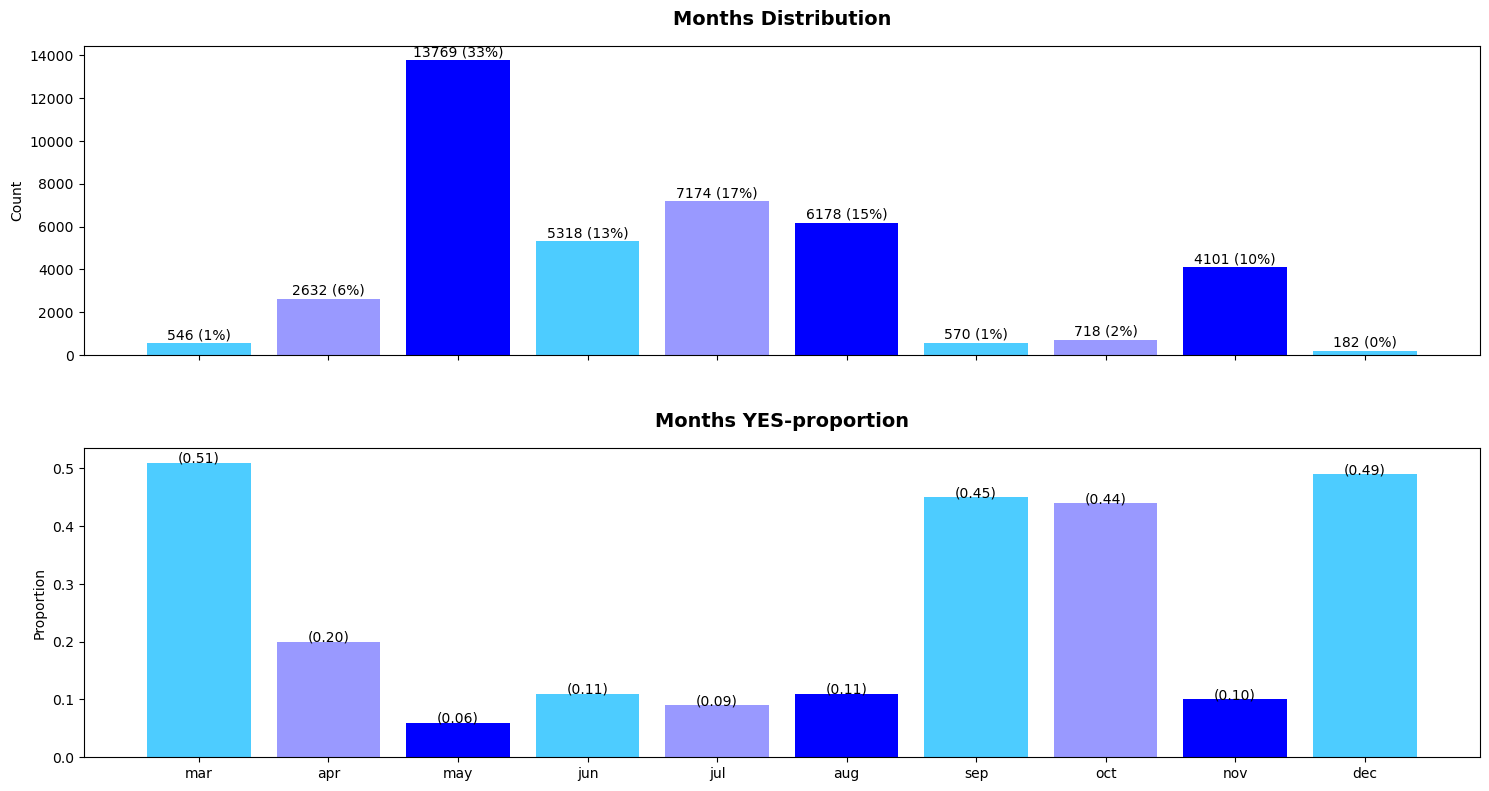

In [21]:
univariate_analysis_categorical_var(tele_df, 'months_order', 'Months')

The distribution of the 'month' feature shows that certain months have higher customer engagement compared to others. For instance, May, July, and August have the lowest counts in terms of yes-proportion, indicating that marketing campaigns during these months may be lest effective. This insight can help in planning future marketing strategies to optimize customer outreach based on seasonal trends. Need to analyze this furthur.

From the dataset description we informed that data spans from may 2008 to nov 2010 with 41188 rows and 20 columns in bank-additional-full.csv files.

Considering the given dataset is about customer subscribe for term deposit will depends on each customers monthly economic and social context and, undoubtedly,economic factors had an impact on customer's decision i.e., target y. Hence, decide to analyze deeper the month dimension.


In [22]:
# Here we just get an insight of how months are going one by one in the dataset.
# Just a remainder: the observations are ordered by date (from May 2008 to November 2010.
months_arr = [
    [i, m]
    for i, m in enumerate(tele_df['month'])
    if i==0 or m != tele_df['month'].iloc[i-1]    ## “Take this row if it’s the first row OR if the month changed compared to the previous row.”
]
months_arr = np.array(months_arr)

We've got :

**2008 : [0, 27690)**

**2009 : [27690, 39130)**

**2010 : [39130, 41188)**

In [23]:
tele_df['year'] = np.hstack((np.array([2008] * (27690 - 0)),
           np.array([2009] * (39130 - 27690)),
           np.array([2010] * (41188 - 39130))))


In [24]:
# Reorder columns to have year and month together
cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'year', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary']

tele_data = tele_df[cols]
tele_data.head()

,age,job,marital,education,default,housing,loan,contact,month,year,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,y_binary
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,2008,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,2008,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,2008,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,2008,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,2008,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [25]:
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'month_num',
       'age_groups', 'old_new', 'y_binary', 'months_order', 'year'],
      dtype='object')

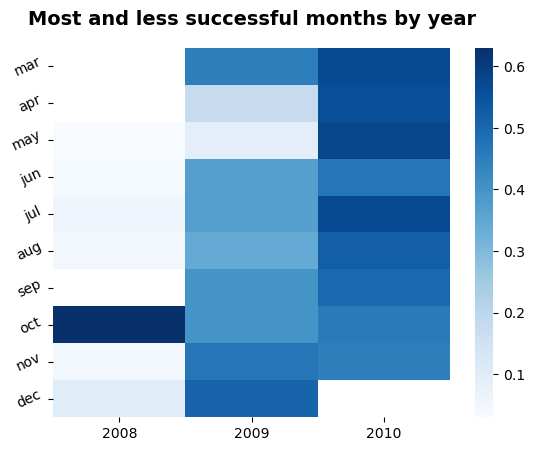

In [26]:
# Compute average conversion rate for each month-year combination
conv_rate = pd.crosstab(tele_df['months_order'], tele_df['year'], values=tele_df['y_binary'], aggfunc='mean').round(2)

ax = sns.heatmap(conv_rate, annot=False, cmap='Blues', cbar=True)
ax.set_title('Most and less successful months by year', fontsize=14, fontweight='bold', y=1.04)
ax.tick_params(axis='y', rotation=25)
ax.set_ylabel('')
ax.set_xlabel('')
plt.show()

- Cannot see any noticeable patterns in conversion rates between years.

Let's analyze months by taking year into account.

### **Dimension : Year**

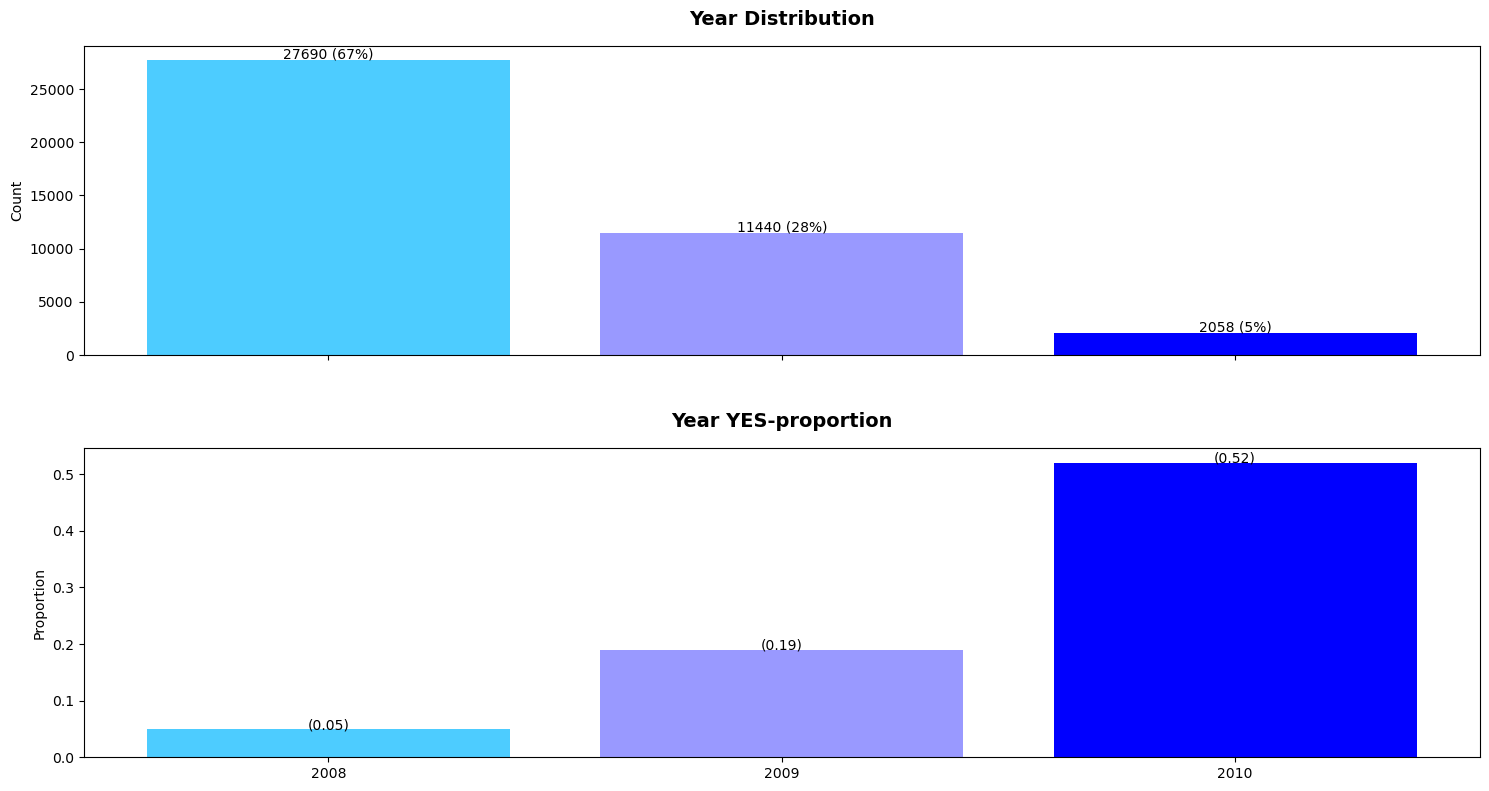

In [27]:
univariate_analysis_categorical_var(tele_df, 'year', 'Year')

**Insights**

- The distribution is highly uneven
- Most observations were got in 2008 (~ 67%)
- The most successful year was 2010 (YES-proportion ~ 0.52)

Let's check what each year hiding:

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap_bivariate_analysis(df, var1, var2, y_binary, fig=None, ax=None):
    """
    Plot heatmap for total observed and yes counts for given variables.
    Allows passing existing fig and ax for flexible plotting.
    """
    # Total counts
    total_counts = pd.crosstab(df[var1], df[var2], values=df[y_binary], aggfunc='count')
    # Yes counts (conversion rate)
    yes_counts = pd.crosstab(df[var1], df[var2], values=df[y_binary], aggfunc='mean').round(2)

    # If no fig/ax provided, create new ones
    if fig is None or ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Total observed heatmap
    scatter = sns.heatmap(total_counts, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax[0])
    colorbar = scatter.collections[0].colorbar
    colorbar.set_ticks([])
    ax[0].set_title(f'Total Observed Counts by\n{var1} and {var2}', fontsize=14, fontweight='bold', y=1.04)
    ax[0].tick_params(axis='y', rotation=25)
    ax[0].set_ylabel('')
    ax[0].set_xlabel('')

    # Yes counts heatmap
    heat_map = sns.heatmap(yes_counts, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax[1])
    colorbar = heat_map.collections[0].colorbar
    colorbar.set_ticks([])
    ax[1].set_title(f'Conversion Rate by\n{var1} and {var2}', fontsize=14, fontweight='bold', y=1.04)
    ax[1].tick_params(axis='y', rotation=25)
    ax[1].set_ylabel('')
    ax[1].set_xlabel('')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    return fig, ax


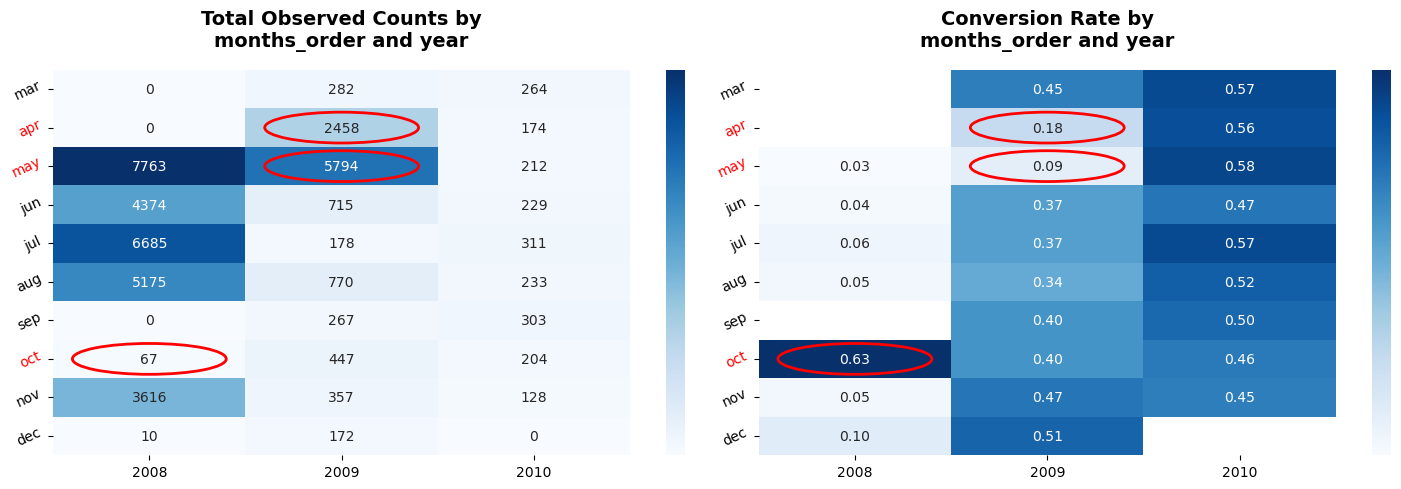

In [29]:
# Create new plot
fig, ax = plot_heatmap_bivariate_analysis(tele_df, 'months_order', 'year', 'y_binary')
ax[0].add_artist(plt.Circle(xy=(0.5, 7.5), radius=0.4, color='red', fill=False, lw=2))
ax[0].add_artist(plt.Circle(xy=(1.5, 1.5), radius=0.4, fill=False, color='red', lw=2))
ax[0].add_artist(plt.Circle(xy=(1.5, 2.5), radius=0.4, fill=False, color='red', lw=2))

ax[1].add_artist(plt.Circle(xy=(0.5, 7.5), radius=0.4, color='red', fill=False, lw=2))
ax[1].add_artist(plt.Circle(xy=(1.5, 1.5), radius=0.4, fill=False, color='red', lw=2))
ax[1].add_artist(plt.Circle(xy=(1.5, 2.5), radius=0.4, fill=False, color='red', lw=2))

for tick1, tick2 in zip(ax[0].get_yticklabels(), ax[1].get_yticklabels()):
    if tick1.get_text() in ['apr', 'may', 'oct']:
        tick1.set_color('red')
    if tick2.get_text() in ['apr', 'may', 'oct']:
        tick2.set_color('red')

plt.tight_layout();
#plt.show()

- Each year has an uneven distribution of observations by month
- It's like we have anomalies at Oct, 2008 and at Apr and May, 2009


Let's dig into 2008 to see if October has any strange things:

In [30]:
df_2008 = tele_df[tele_df['year'] == 2008]

# Segregrate numeric and categorical variables
numeric_vars = df_2008.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()
numeric_cols = [cols for cols in numeric_vars if cols != 'year']

categorical_vars = df_2008.select_dtypes(include=['object', 'category']).columns.tolist()

We will compare median values of numeric columns for a year 2008:

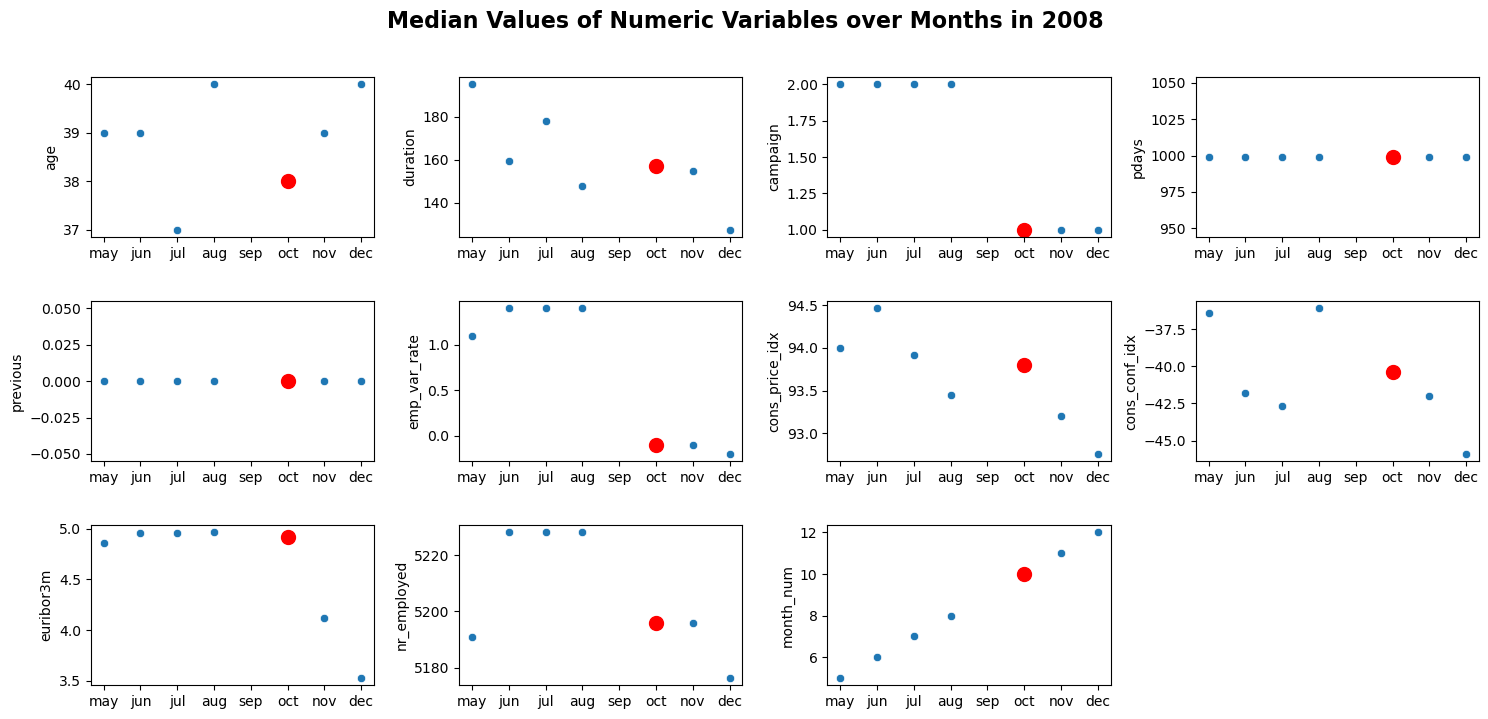

In [31]:
df_2008_median = df_2008.groupby('months_order').median(numeric_only=True)

# Plot numeric variables trends over months in 2008
fig, ax = plt.subplots(3, 4, figsize=(15, 7))
ax = ax.flatten()

for ax_, col in zip(ax[:-1], numeric_cols):
    sns.scatterplot(data=df_2008_median, 
                    x=df_2008_median.index, 
                    y=col, 
                    ax=ax_)
    ax_.set_xlabel('')
    ax_.plot('oct', df_2008_median.loc['oct', col], marker='o', markersize=10, color='red')
    
fig.delaxes(ax[-1]) # to remove unused subplots

plt.suptitle("Median Values of Numeric Variables over Months in 2008", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

Mann-Whitney U Test Results (October vs Other Months in 2008):

               oct_median other_months_median median_diff effect_size  \
age                  38.0                39.0        -1.0   -0.006797   
duration            157.0               171.0       -14.0    -0.00702   
campaign              1.0                 2.0        -1.0   -0.051233   
pdays               999.0               999.0         0.0    0.000108   
previous              0.0                 0.0         0.0    0.000285   
emp_var_rate         -0.1                 1.4        -1.5   -0.073894   
cons_price_idx     93.798              93.918       -0.12    -0.03087   
cons_conf_idx       -40.4               -41.8         1.4    0.005382   
euribor3m           4.921               4.958      -0.037    0.017287   
nr_employed        5195.8              5228.1       -32.3   -0.026065   
month_num            10.0                 7.0         3.0    0.062754   
y_binary              1.0                 0.0         1.0   

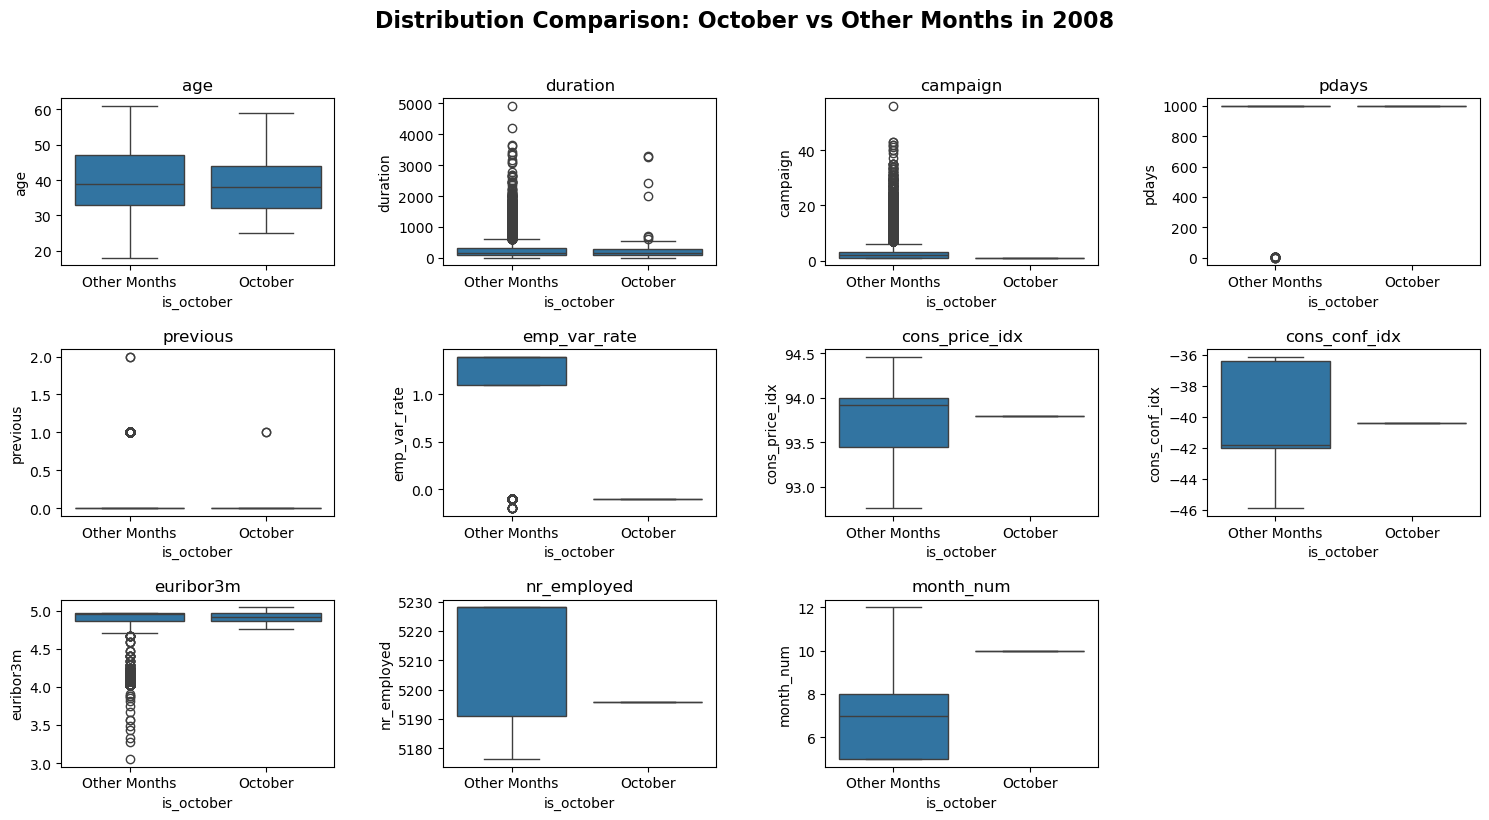

In [32]:
# Statistical approach: Compare October vs other months in 2008
october_data = df_2008[df_2008['month'] == 'oct'][numeric_cols]
other_months_data = df_2008[df_2008['month'] != 'oct'][numeric_cols]

# Perform Mann-Whitney U test (non-parametric test for distribution differences, good for median)

print("Mann-Whitney U Test Results (October vs Other Months in 2008):\n")
p_values = {}
results = {}
for col in numeric_cols:
    x, y = october_data[col].dropna(), other_months_data[col].dropna()
    stat, p_value = stats.mannwhitneyu(october_data[col].dropna(), other_months_data[col].dropna())
    p_values[col] = p_value
    significance = "Significant" if p_value < 0.05 else "Not Significant"
    
    # Median difference(effect size proxy)
    median_diff = x.median() - y.median()

    # Rank-biserial correlation (effect size) 
    n1, n2 = len(x), len(y) 
    N = n1 + n2 
    mean_U = n1 * n2 / 2 
    std_U = np.sqrt(n1 * n2 * (N + 1) / 12) 
    Z = (stat - mean_U) / std_U 
    r = Z / np.sqrt(N)
    
    #print(f"{col}: p-value = {p_value:.4f} ({significance}), Effect_size = {median_diff:.2f}")

    # Interpret effect size
    if r < 0.1:
        effect_interpretation = "negligible"
    elif r < 0.3:
        effect_interpretation = "small"
    elif r < 0.5:
        effect_interpretation = "medium"
    else:
        effect_interpretation = "large"

    results[col] = {
        'oct_median' : x.median(),
        'other_months_median': y.median(),
        'median_diff':median_diff,
        'effect_size': r,
        'effect_interpretation': effect_interpretation,
        'pvalue': p_value,
        'significance': significance
    }

df = pd.DataFrame(results).T
print(df)
print()
# Visualize: Compare distributions using box plots
fig, ax = plt.subplots(3, 4, figsize=(15, 8))
ax = ax.flatten()

for ax_, col in zip(ax[:-1], numeric_cols):
    # Create a temporary dataframe for plotting
    plot_data = df_2008[[col, 'month']].copy()
    plot_data['is_october'] = plot_data['month'] == 'oct'
    sns.boxplot(x='is_october', y=col, data=plot_data, ax=ax_)
    ax_.set_xticklabels(['Other Months', 'October'])
    ax_.set_title(col)


fig.delaxes(ax[-1]) # to remove unused subplots
plt.suptitle("Distribution Comparison: October vs Other Months in 2008", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()
    

October shows some differences, but not enough across all variables to be considered fully distinct.

There is nothing unique about October 2008 in terms of median values of numeric variables. Let's check categorical columns.

                   Distribution of categorical variables over months in year 2008                   


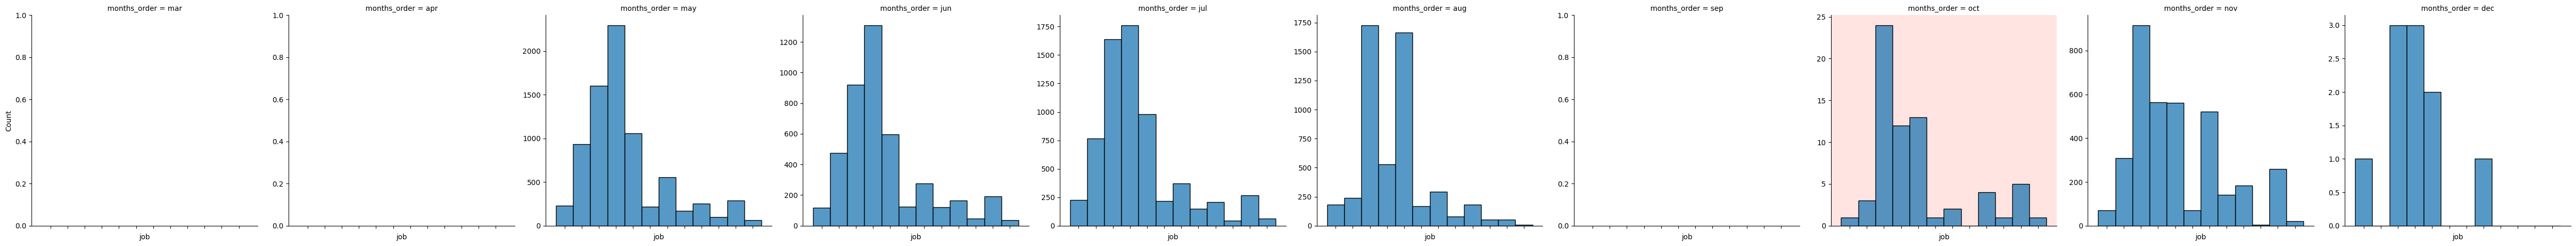

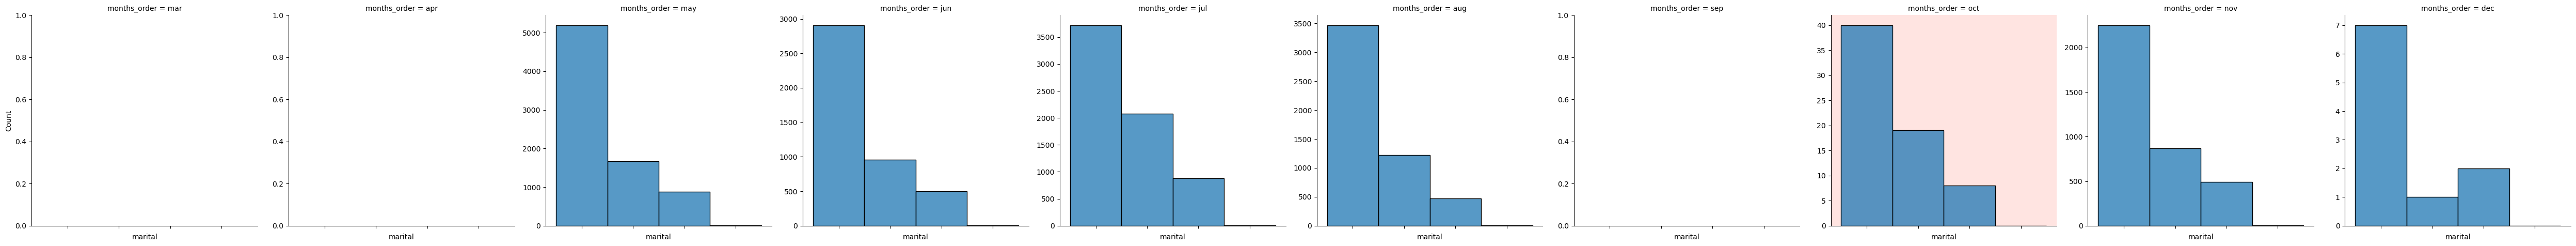

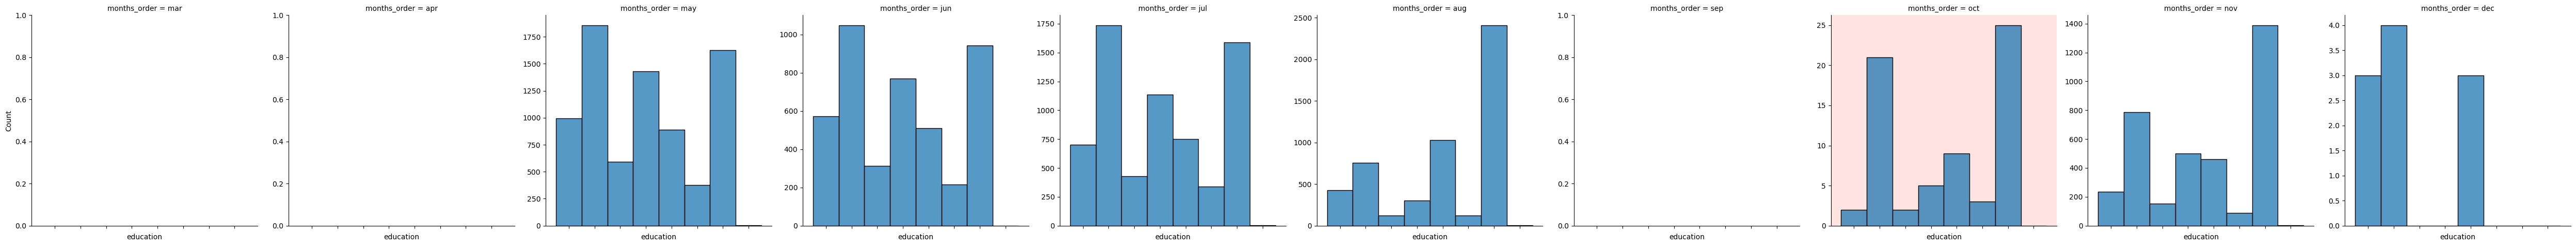

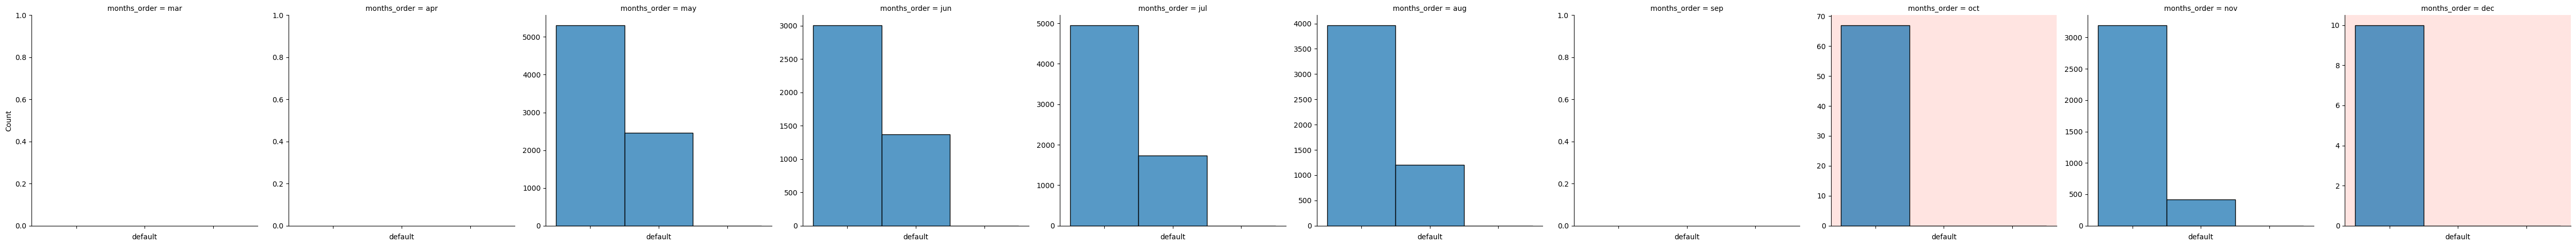

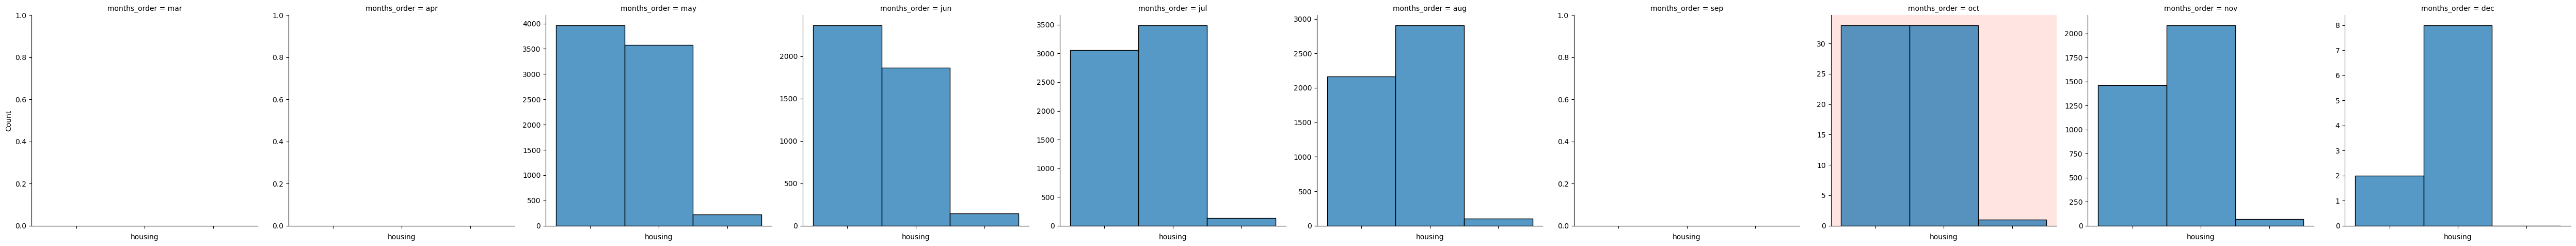

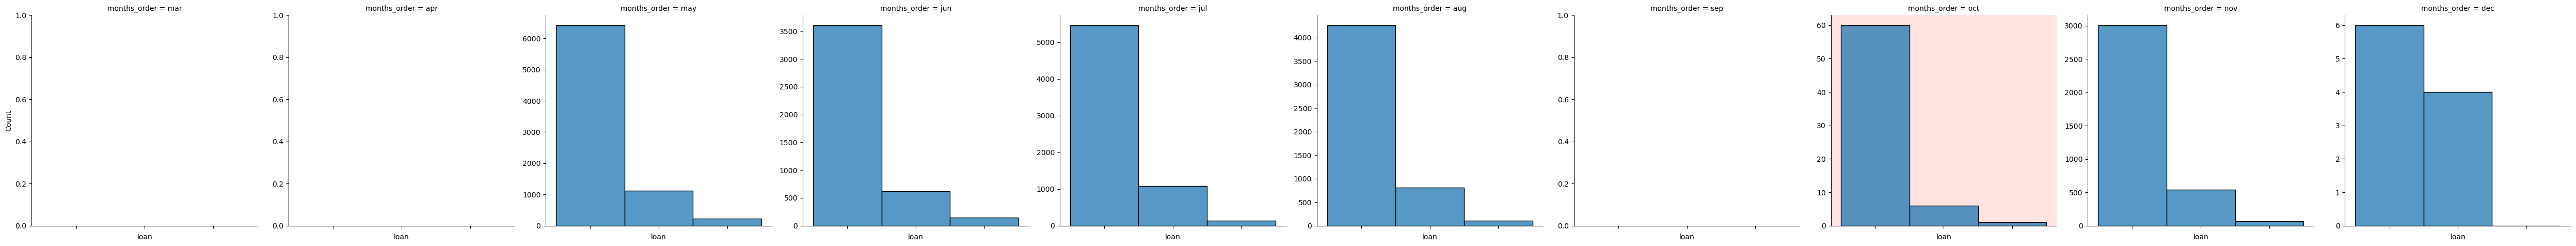

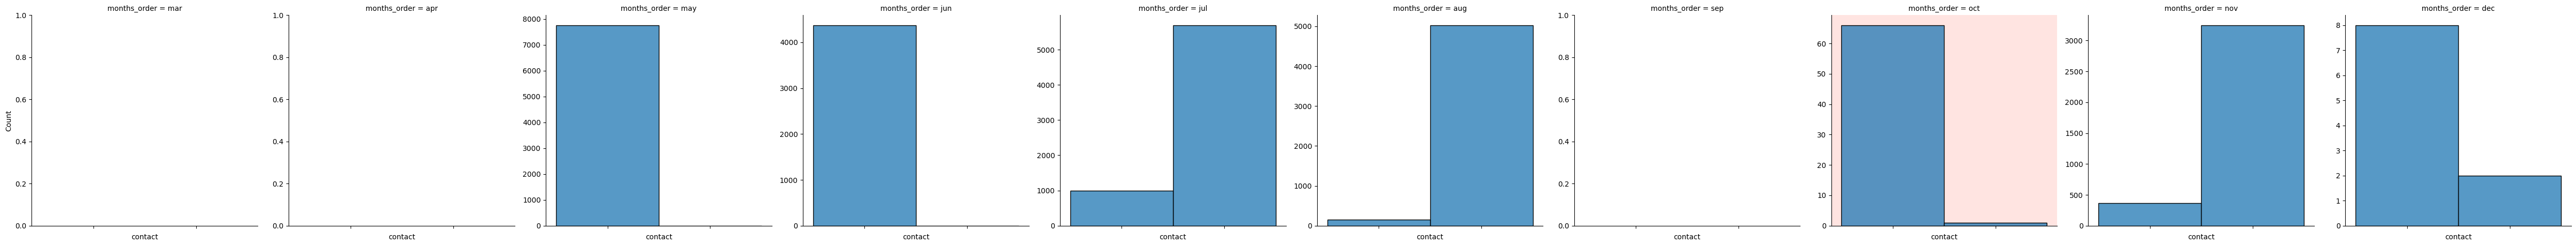

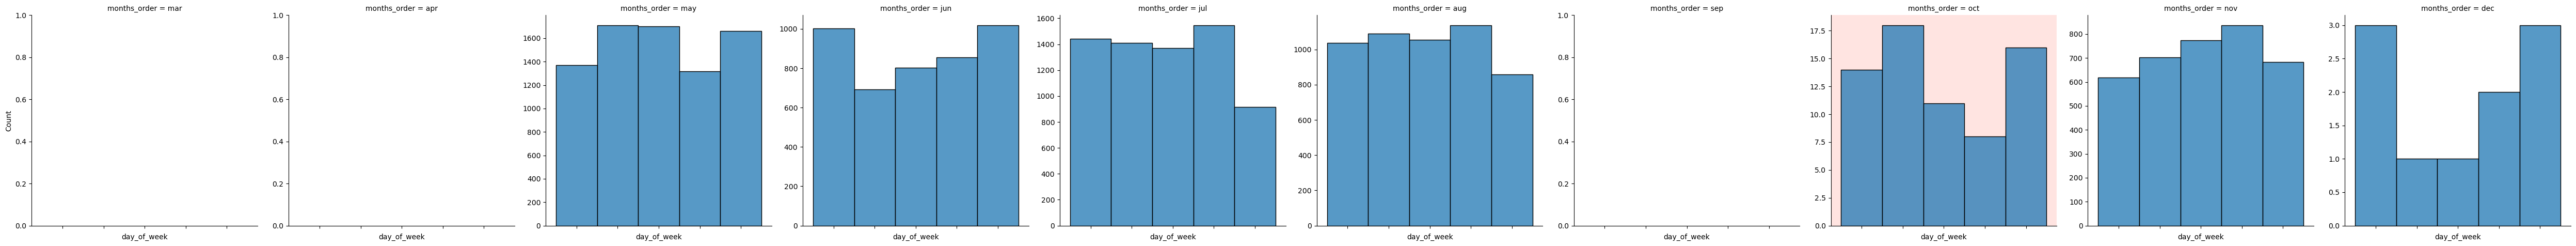

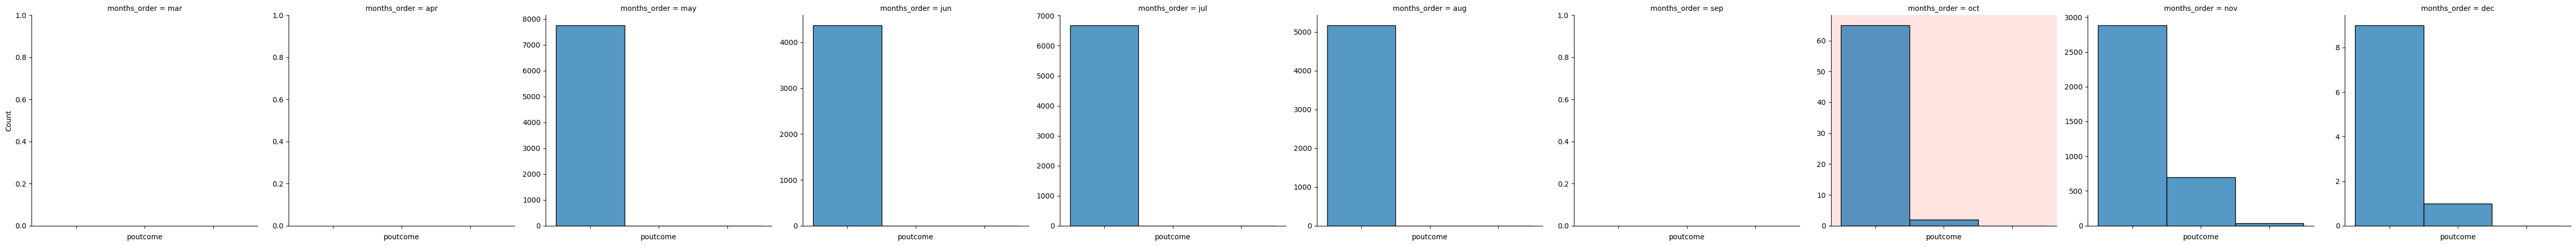

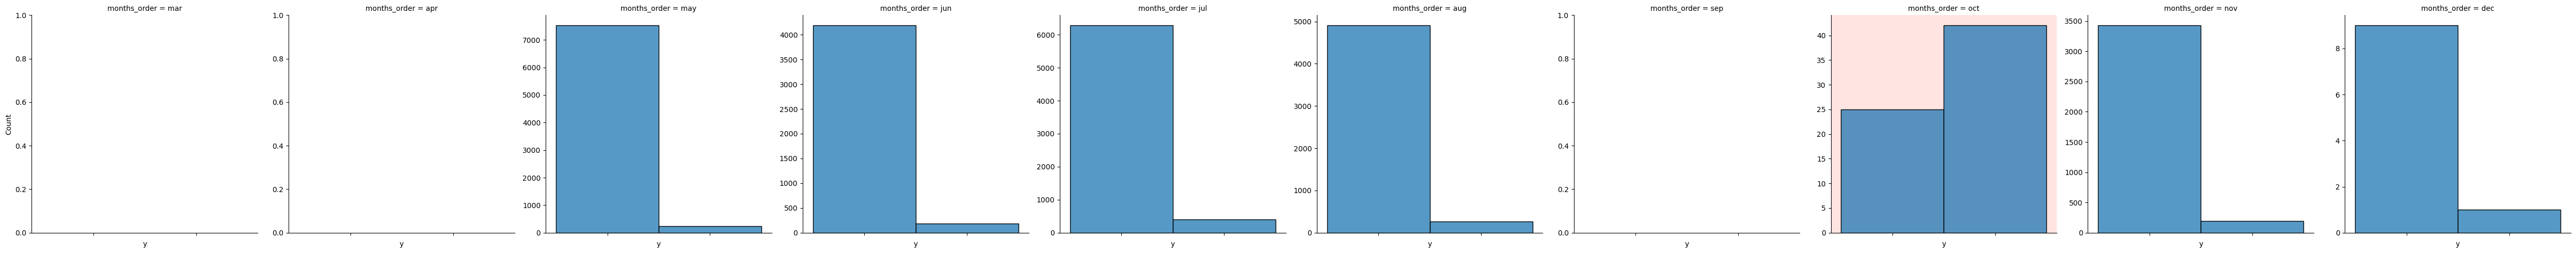

In [33]:
print("=" * 100)
print(f"{'Distribution of categorical variables over months in year 2008':^100}")
print("="*100)

cat_col = [col for col in categorical_vars if col not in ['month', 'months_order','age_groups', 'old_new']]
for row in cat_col:
    g = sns.displot(
        data=df_2008,
        x=df_2008[row],
        col='months_order',
        height=5, facet_kws={'sharey':False}
    )

    for col_val, ax in g.axes_dict.items():
        if col_val == 'oct' or col_val == 'dec' and row == 'default':
            ax.set_facecolor('mistyrose')

    for axes in g.axes.flatten():
        _ = axes.set_xticklabels([])

plt.tight_layout();

Will look closely to **default** feature

What we will see: Oct and Dec don't have **unknown** and **yes** at all.

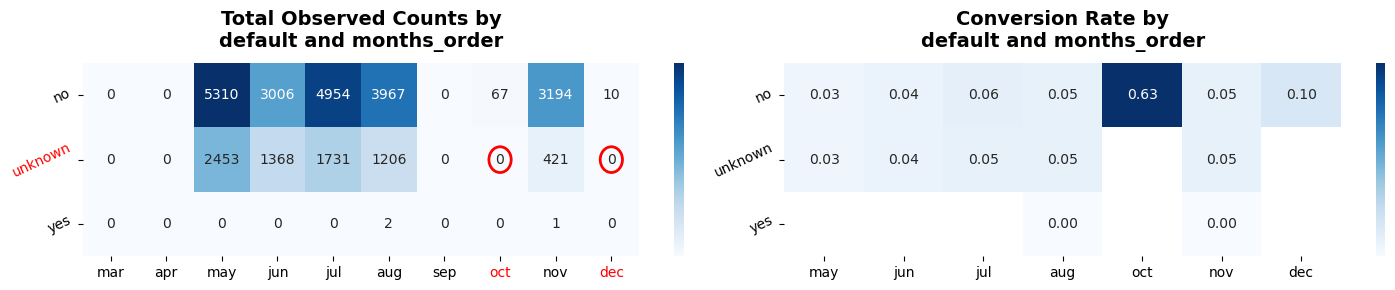

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(15, 3))
plot_heatmap_bivariate_analysis(df_2008, 'default', 'months_order', 'y_binary', fig=fig, ax=ax)

ax[0].add_artist(plt.Circle(xy = (7.5, 1.5), radius=0.2, color='red', fill=False, lw=2))
ax[0].add_artist(plt.Circle(xy = (9.5, 1.5), radius=0.2, color='red', fill=False, lw=2))

# Color y-ticks
for tick1 in ax[0].get_yticklabels():
    if tick1.get_text() in ['unknown']:
        tick1.set_color('red')

# Color x-ticks
for tick2 in ax[0].get_xticklabels():
    if tick2.get_text() in ['oct', 'dec']:
        tick2.set_color('red')

plt.tight_layout();

Now, let's draw attention to another months but of year 2009.

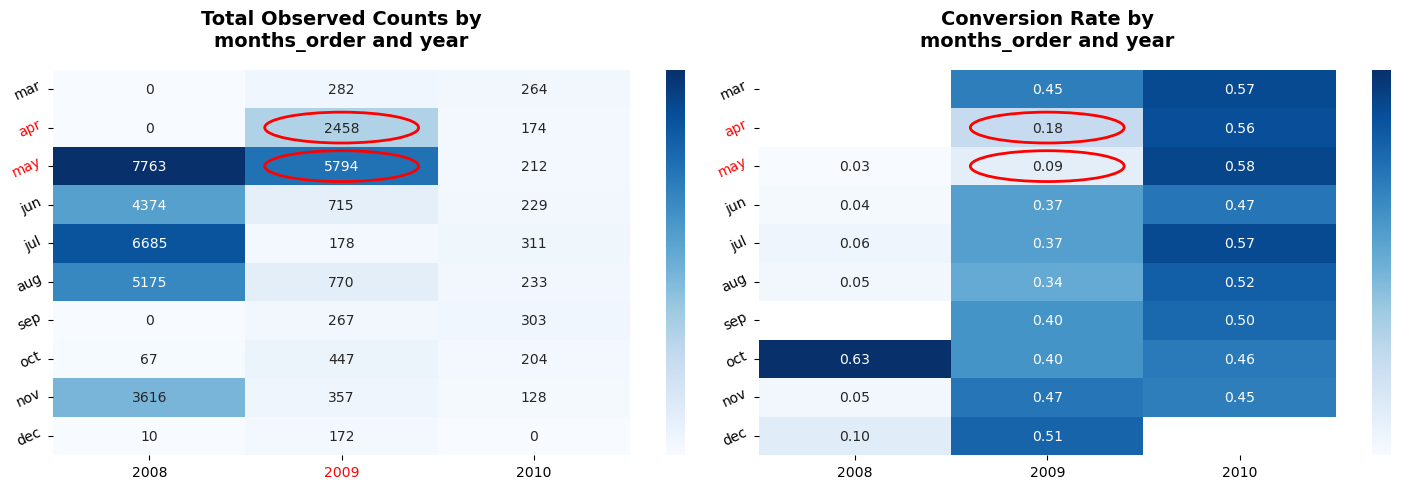

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_heatmap_bivariate_analysis(tele_df, 'months_order', 'year', 'y_binary', fig, ax)

ax[0].add_artist(plt.Circle(xy=(1.5, 1.5), radius=0.4, color='red', fill=False, lw=2))
ax[0].add_artist(plt.Circle(xy=(1.5, 2.5), radius=0.4, color='red', fill=False, lw=2))

ax[1].add_artist(plt.Circle(xy=(1.5, 1.5), radius=0.4, color='red', fill=False, lw=2))
ax[1].add_artist(plt.Circle(xy=(1.5, 2.5), radius=0.4, color='red', fill=False, lw=2))

for tick1, tick2 in zip(ax[0].get_yticklabels(), ax[1].get_yticklabels()):
    if tick1.get_text() in ['apr', 'may']:
        tick1.set_color('red')
    if tick2.get_text() in ['apr', 'may']:
        tick2.set_color('red')

for x1, x2 in zip(ax[0].get_xticklabels(), ax[1].get_xticklabels()):
    if x1.get_text() == '2009':
        x1.set_color('red')
    if x2.get_text == '2009':
        x2.set_color('red')
plt.tight_layout();

Let's dig into year 2009:

In [36]:
df_2009 = tele_df[tele_df['year']==2009]

# Segregrate numeric and categorical variables
numeric_vars = df_2008.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()
numeric_cols = [cols for cols in numeric_vars if cols != 'year']

categorical_vars = df_2008.select_dtypes(include=['object', 'category']).columns.tolist()


Again, we will compare median values of numeric columns across months but for year 2009:

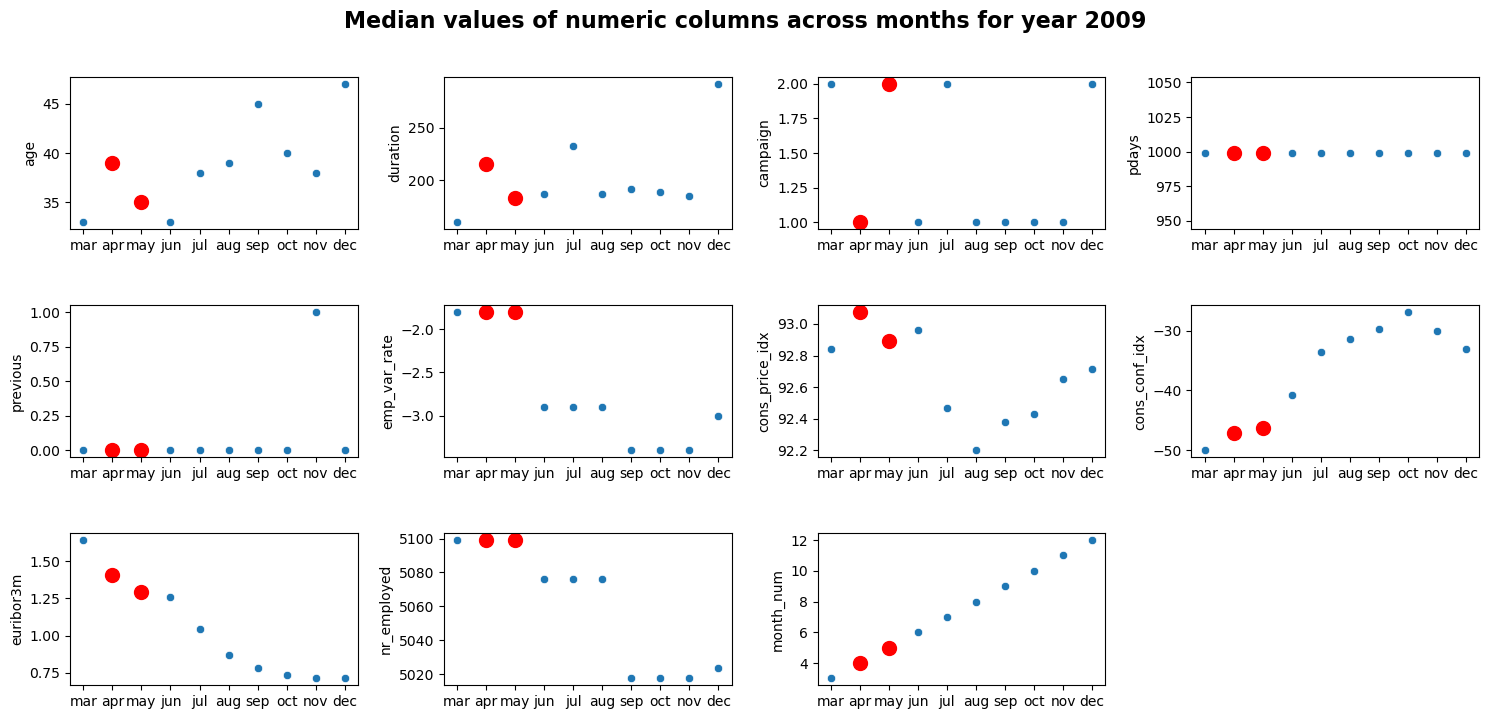

In [37]:
df_2009_median = df_2009.groupby(['months_order'])[numeric_cols].median()

# Plot median values of numeric columns across months for year 2009
fig, ax = plt.subplots(3, 4, figsize=(15, 7))
ax = ax.flatten()

for ax_, col in zip(ax[:-1], numeric_cols):
    sns.scatterplot(
        data=df_2009_median,
        x = df_2009_median.index,
        y=col,
        ax=ax_
    )
    ax_.set_xlabel('')
    ax_.plot('apr', df_2009_median.loc['apr', col], marker='o', ms=10, c='r')
    ax_.plot('may', df_2009_median.loc['may',col], 'o', ms=10, c='r')

fig.delaxes(ax[-1])
plt.suptitle("Median values of numeric columns across months for year 2009", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

Mann-Whitney U Test Results (April vs Other Months in 2009):


               apr_median not_apr_median median_diff effect_size  \
age                  39.0           36.0         3.0    0.075643   
duration            216.0          186.0        30.0    0.059023   
campaign              1.0            2.0        -1.0   -0.041373   
pdays               999.0          999.0         0.0     0.03453   
previous              0.0            0.0         0.0   -0.048366   
emp_var_rate         -1.8           -1.8         0.0    0.230152   
cons_price_idx     93.075         92.893       0.182    0.711366   
cons_conf_idx       -47.1          -46.2        -0.9   -0.666698   
euribor3m           1.405          1.266       0.139    0.666698   
nr_employed        5099.1         5099.1         0.0    0.230152   
month_num             4.0            5.0        -1.0   -0.666698   
y_binary              0.0            0.0         0.0   -0.013531   

               effect_interpretation p_value signifi

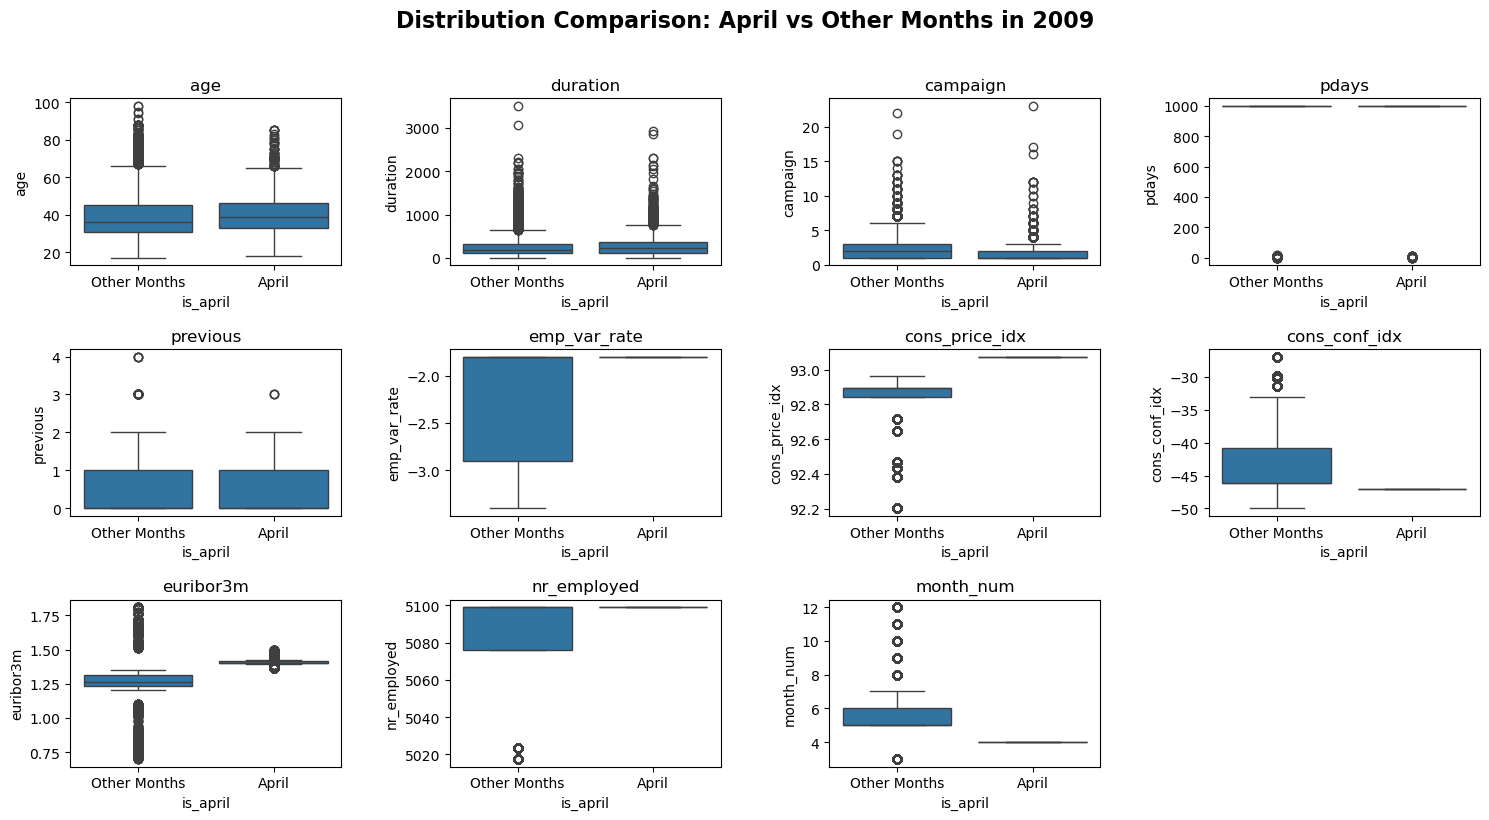

In [38]:
# Statistical approach: Compare April vs other months in 2009
april_data = df_2009[df_2009['month'] == 'apr'][numeric_cols]
other_months_data = df_2009[df_2009['month'] != 'apr'][numeric_cols]

# Perform Mann-Whitney U test (non-parametric test for distribution differences, good for median)

print("Mann-Whitney U Test Results (April vs Other Months in 2009):\n")
p_values = {}
results = {}
for col in numeric_cols:
    x, y = april_data[col].dropna(), other_months_data[col].dropna()
    stat, p_value = stats.mannwhitneyu(x, y, alternative='two-sided')
    p_values[col] = p_value
    significance = "Significant" if p_value < 0.05 else "Not Significant"

    # Median difference (effect size proxy) 
    median_diff = x.median() - y.median()

    # Rank-biserial correlation (effect size) 
    n1, n2 = len(x), len(y) 
    N = n1 + n2 
    mean_U = n1 * n2 / 2 
    std_U = np.sqrt(n1 * n2 * (N + 1) / 12) 
    Z = (stat - mean_U) / std_U 
    r = Z / np.sqrt(N)

    # Interpret effect size
    if r < 0.1:
        effect_interpretation = "negligible"
    elif r < 0.3:
        effect_interpretation = "small"
    elif r < 0.5:
        effect_interpretation = "medium"
    else:
        effect_interpretation = "large"

    #print(f"{col}: p-value = {p_value:.4f} ({significance}) (Effect-size = {median_diff:.3f})")

    results[col] = {
        'apr_median': x.median(),
        'not_apr_median': y.median(),
        'median_diff': median_diff,
        'effect_size': r,
        'effect_interpretation':effect_interpretation,
        'p_value': p_value.round(2),
        'significance':significance
    }

results_df = pd.DataFrame(results).T
print()
print(results_df)

# Visualize: Compare distributions using box plots
fig, ax = plt.subplots(3, 4, figsize=(15, 8))
ax = ax.flatten()

for ax_, col in zip(ax[:-1], numeric_cols):
    # Create a temporary dataframe for plotting
    plot_data = df_2009[[col, 'month']].copy()
    plot_data['is_april'] = plot_data['month'] == 'apr'
    sns.boxplot(x='is_april', y=col, data=plot_data, ax=ax_)
    ax_.set_xticklabels(['Other Months', 'April'])
    ax_.set_title(col)

fig.delaxes(ax[-1]) # to remove unused subplots
plt.suptitle("Distribution Comparison: April vs Other Months in 2009", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

Mann-Whitney U Test Results (April vs Other Months in 2009):




               may_median other_months_median median_diff effect_size  \
age                  35.0                38.0        -3.0       -0.13   
duration            183.0               201.0       -18.0       -0.07   
campaign              2.0                 1.0         1.0        0.12   
pdays               999.0               999.0         0.0        0.07   
previous              0.0                 0.0         0.0       -0.01   
emp_var_rate         -1.8                -2.9         1.1        0.45   
cons_price_idx     92.893              92.963       -0.07       -0.11   
cons_conf_idx       -46.2               -40.8        -5.4       -0.03   
euribor3m           1.291               1.268       0.023       -0.02   
nr_employed        5099.1              5076.2        22.9        0.45   
month_num             5.0                 6.0        -1.0       -0.03   
y_binary              0.0                 0.0         0.0       -0.18   

               effect_interpretation     signific

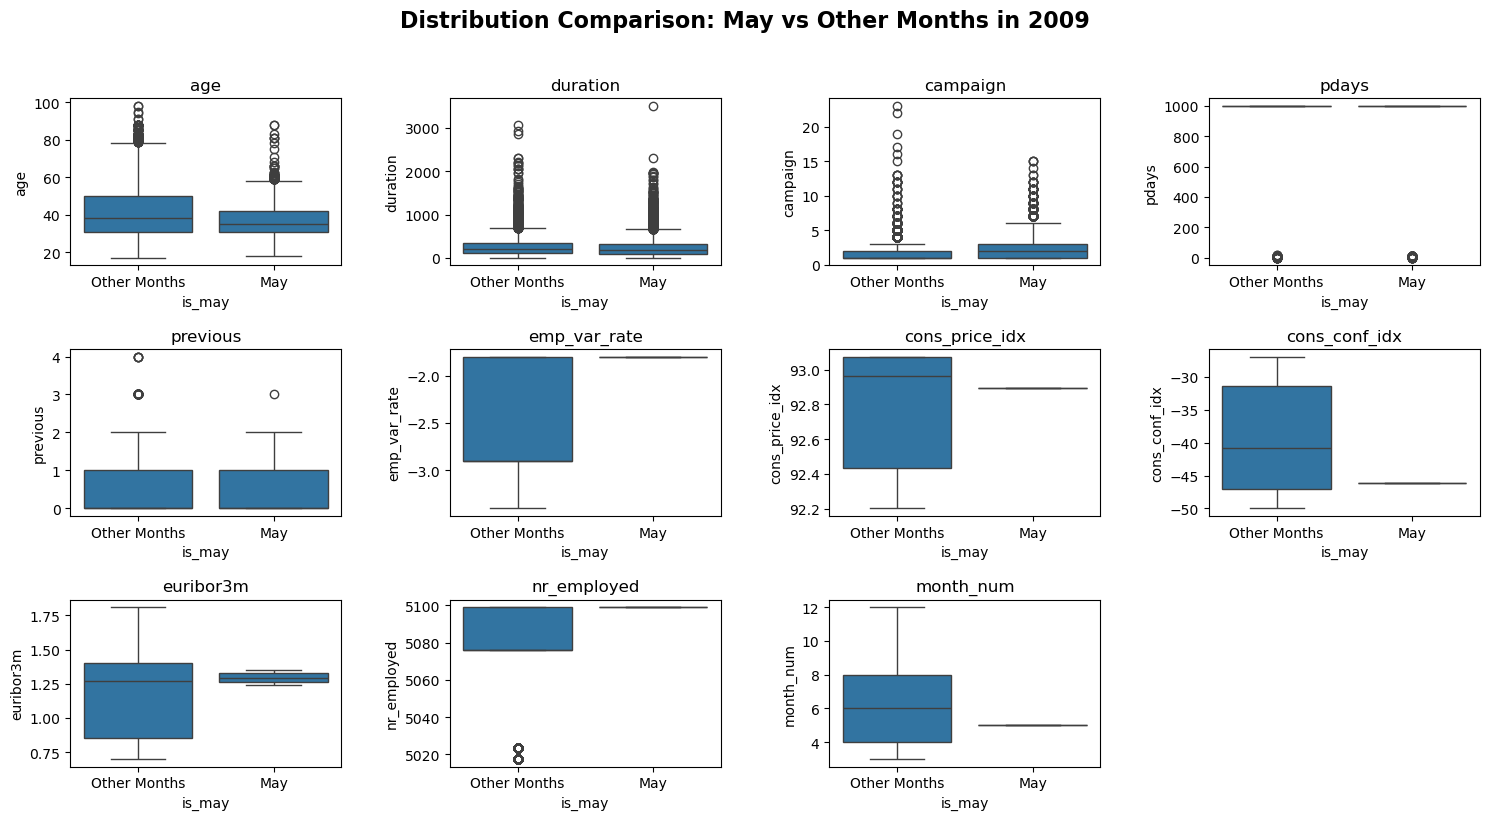

In [39]:
# Statistical approach: Compare May vs other months in 2009
may_data = df_2009[df_2009['month'] == 'may'][numeric_cols]
other_months_data = df_2009[df_2009['month'] != 'may'][numeric_cols]

# Perform Mann-Whitney U test (non-parametric test for distribution differences, good for median)

print("Mann-Whitney U Test Results (April vs Other Months in 2009):\n")
p_values = {}
results = {}
for col in numeric_cols:
    x , y = may_data[col].dropna(), other_months_data[col].dropna()
    stat, p_value = stats.mannwhitneyu(x, y)
    p_values[col] = p_value
    significance = "Significant" if p_value < 0.05 else "Not Significant"
    # Effect size
    median_diff = x.median() - y.median()

    # Rank-biserial correlation (effect size) 
    n1, n2 = len(x), len(y) 
    N = n1 + n2 
    mean_U = n1 * n2 / 2 
    std_U = np.sqrt(n1 * n2 * (N + 1) / 12) 
    Z = (stat - mean_U) / std_U 
    r = Z / np.sqrt(N)
    #print(f"{col}: p-value = {p_value:.4f} ({significance}), Effect_size = {median_diff:.2f}")

    # Interpret effect size
    if r < 0.1:
        effect_interpretation = "negligible"
    elif r < 0.3:
        effect_interpretation = "small"
    elif r < 0.5:
        effect_interpretation = "medium"
    else:
        effect_interpretation = "large"


    results[col] = {
        'may_median': x.median(),
        'other_months_median': y.median(),
        'median_diff': median_diff,
        'effect_size': r.round(2),
        'effect_interpretation': effect_interpretation,
        'significance':significance
    }
df = pd.DataFrame(results).T
print()
print(df)
# Visualize: Compare distributions using box plots
fig, ax = plt.subplots(3, 4, figsize=(15, 8))
ax = ax.flatten()

for ax_, col in zip(ax[:-1], numeric_cols):
    # Create a temporary dataframe for plotting
    plot_data = df_2009[[col, 'month']].copy()
    plot_data['is_may'] = plot_data['month'] == 'may'
    sns.boxplot(x='is_may', y=col, data=plot_data, ax=ax_)
    ax_.set_xticklabels(['Other Months', 'May'])
    ax_.set_title(col)

fig.delaxes(ax[-1]) # to remove unused subplots
plt.suptitle("Distribution Comparison: May vs Other Months in 2009", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

                           Distribution of categorical variables for 2009                           


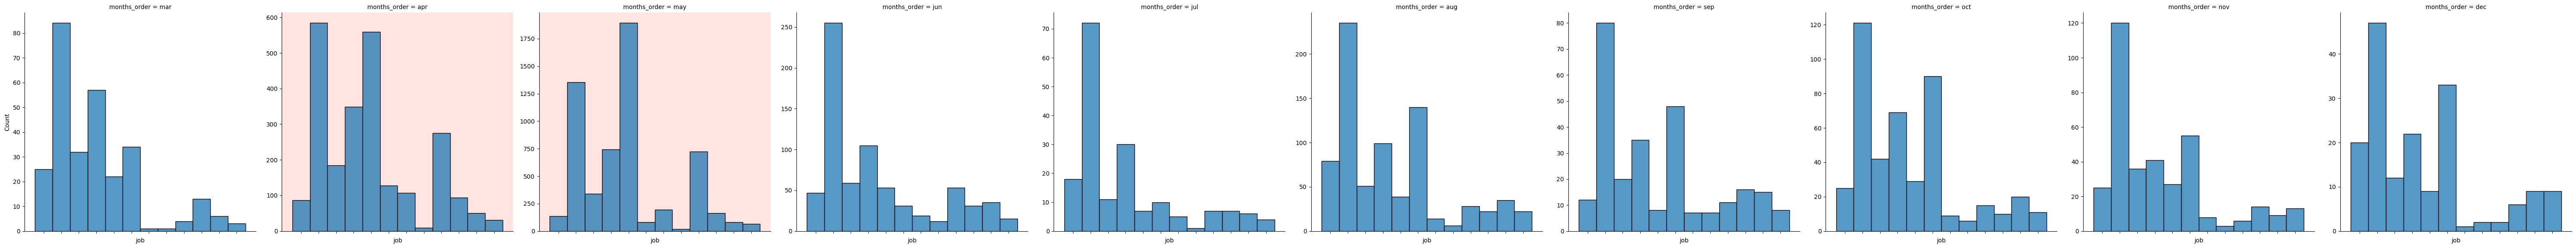

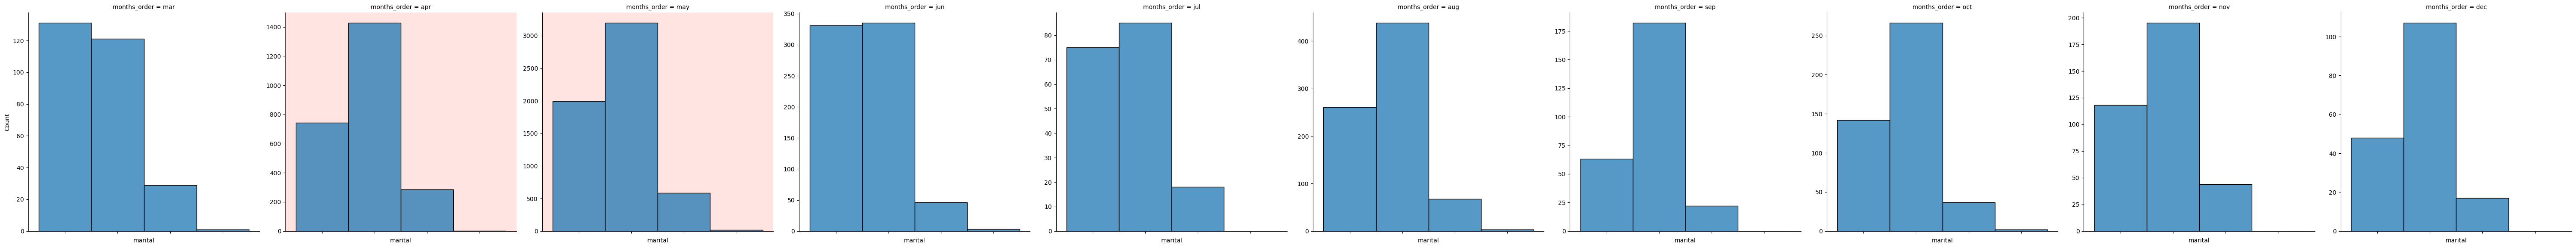

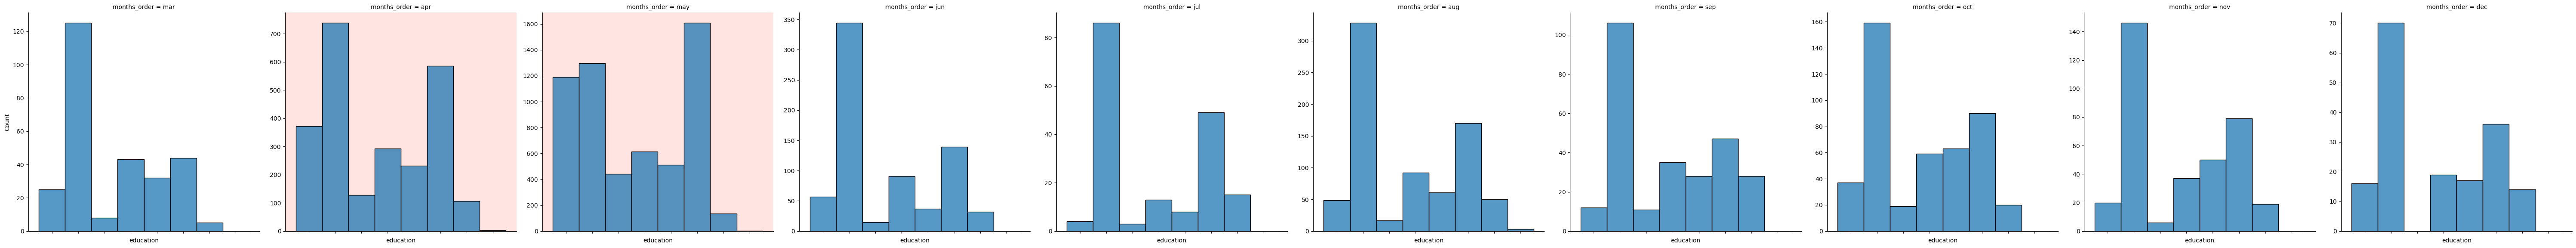

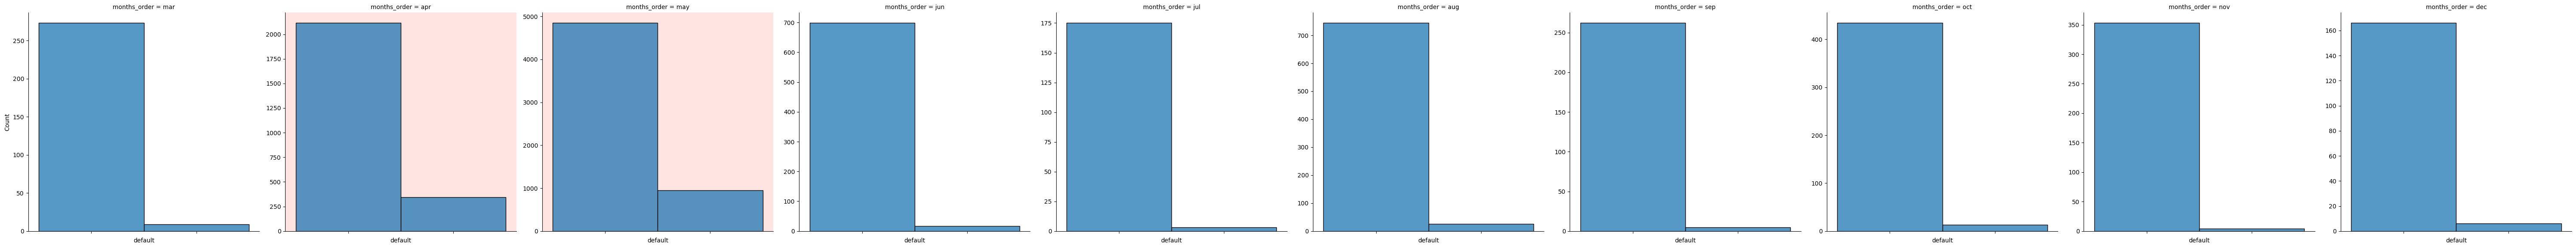

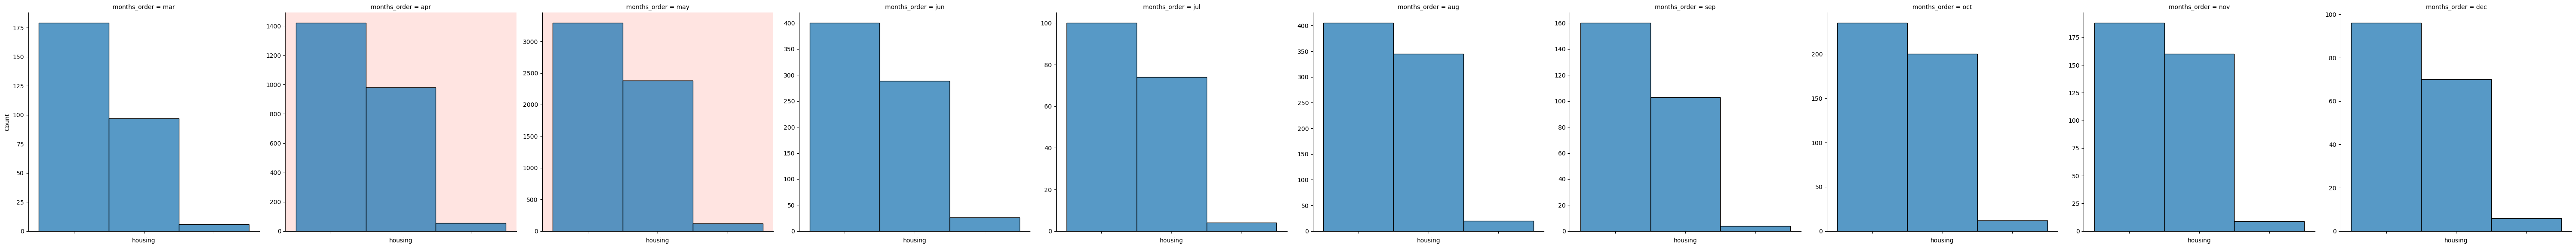

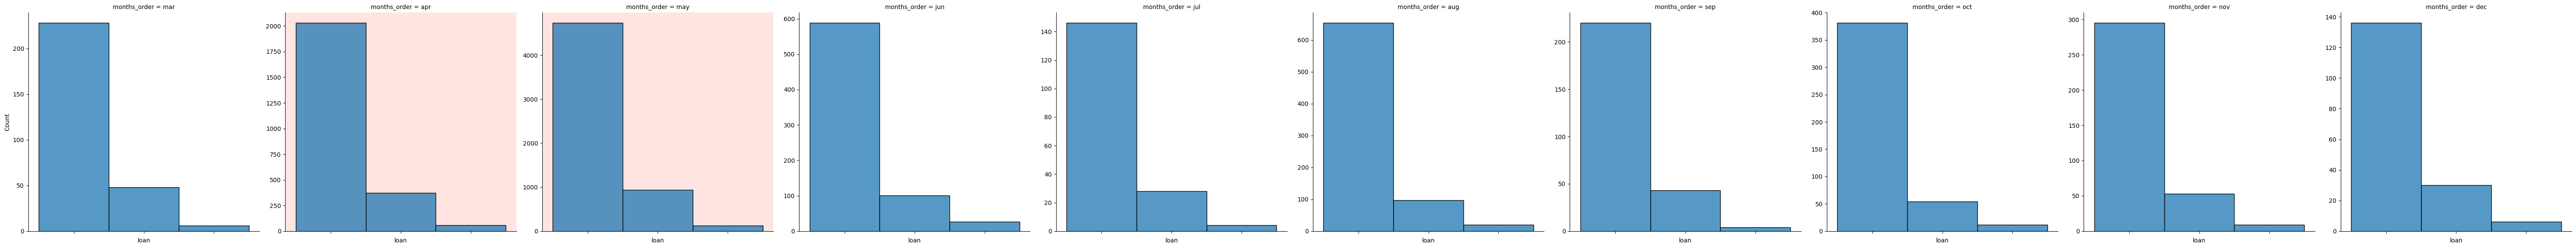

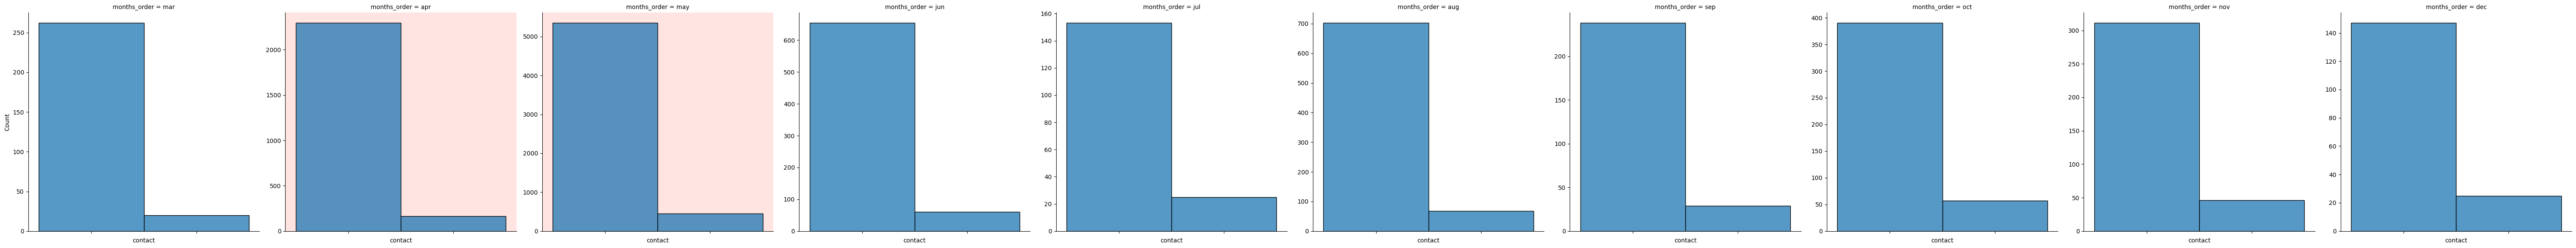

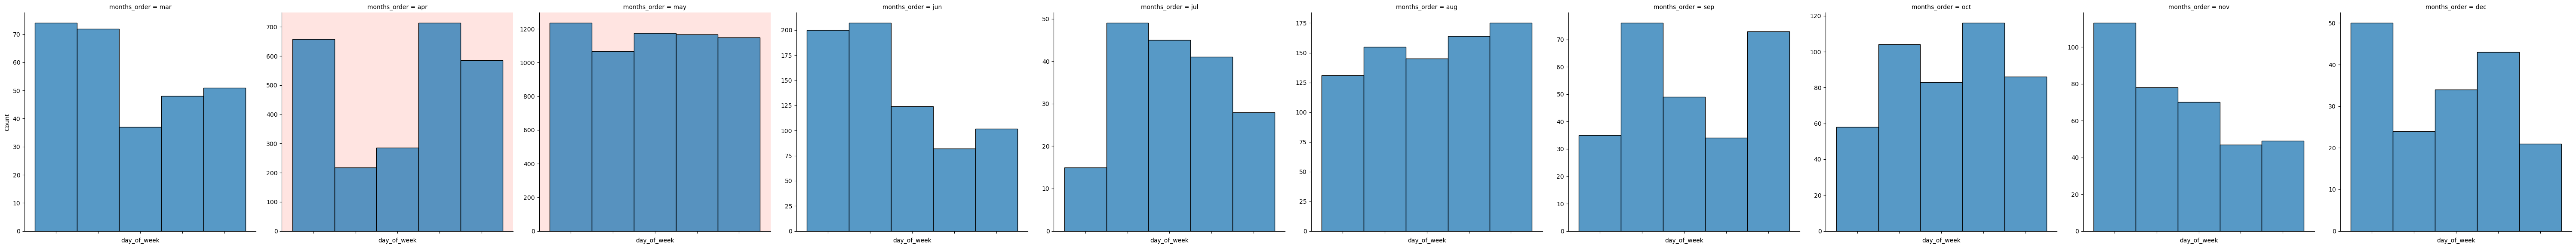

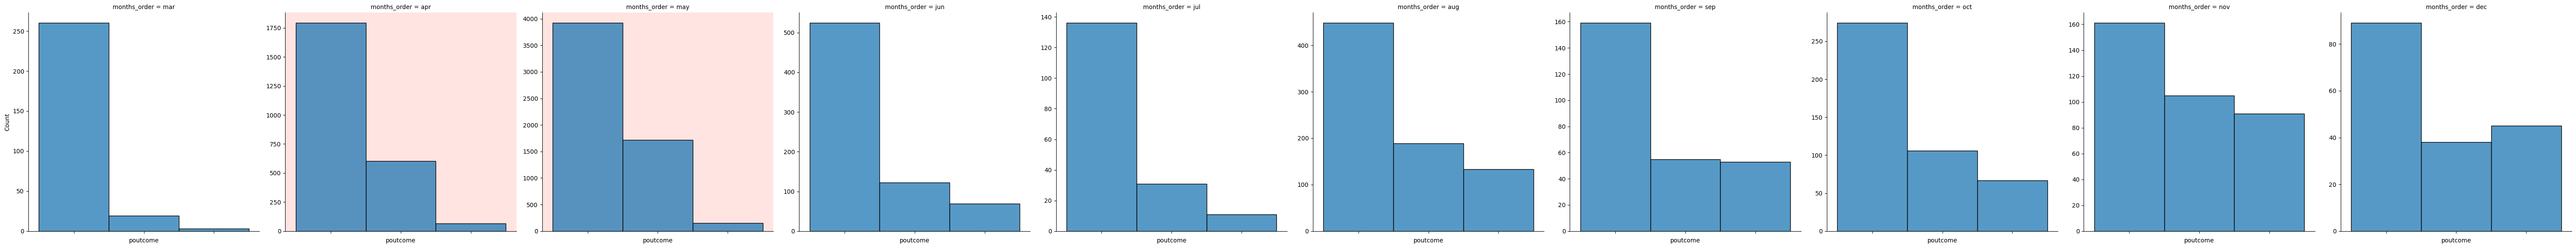

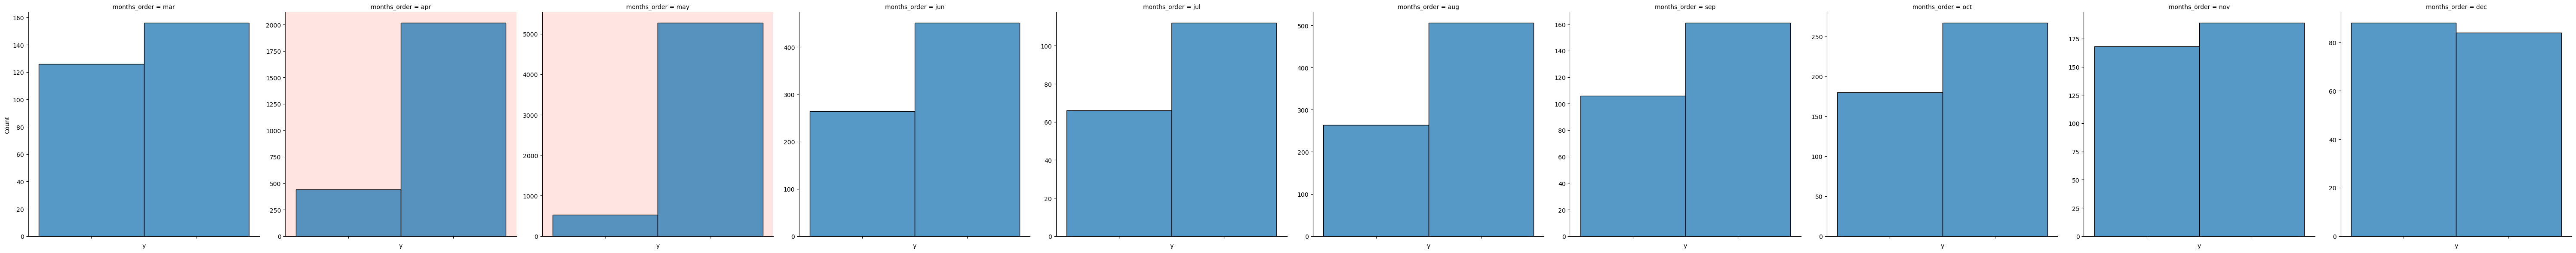

In [40]:
print("="*100)
print(f"{'Distribution of categorical variables for 2009':^100}")
print("="*100)

cat_columns = [col for col in categorical_vars if col not in  ['month', 'months_order','old_new', 'age_groups']]
for col in cat_columns:
    g = sns.displot(
        data=df_2009,
        x=df_2009[col],
        col='months_order',
        height=6,
        facet_kws={'sharey':False}
    )

    for col_val, ax_ in g.axes_dict.items():
        if col_val == 'apr' or col_val == 'may':
            ax_.set_facecolor('mistyrose')
        
    for axes in g.axes.flat:
        _ = axes.set_xticklabels([])

plt.tight_layout();

As you can see, there is nothing unusual for April and May of 2009. So, let's move on then. Maybe, we'll find something interesting studying other features.

Will Check correaltion new variable **year** with other variables.

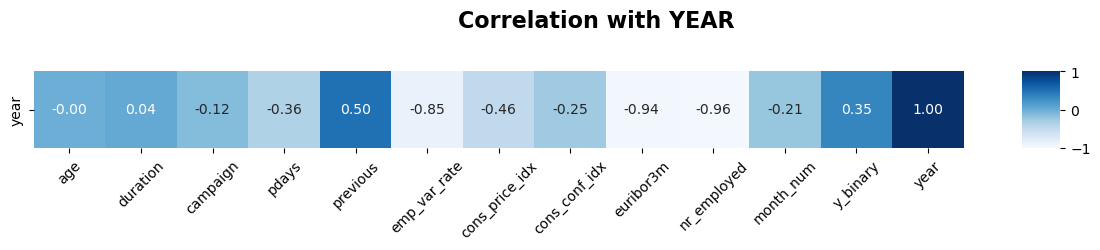

In [41]:
fig, ax = plt.subplots(figsize=(15, 1))

year_corr = tele_df.corr(numeric_only=True, method='pearson')['year']
sns.heatmap([year_corr], annot=True, fmt='.2f',
            cmap=sns.color_palette('Blues', as_cmap=True),
            vmin=-1, vmax=1, cbar_kws={'aspect':2}, 
            xticklabels= year_corr.index, yticklabels=['year'],ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
fig.suptitle("Correlation with YEAR", fontsize=16, fontweight='bold', y=1.50)
plt.tight_layout();

**Key Insights :**

- **Client attributes(age, pdays, campaign)** : Essentially uncorrelated with year. These are individual-level variables that don't depend on calender year.

- **Previous clients :** Later years are associated with **more prior contacts** on average. This implies more repeated client contacts in later campaigns.

- **macro-economics indicator :** show **strong correlation with year**, reflecting impact of the 2008-2010 financial crisis.
    
    - Euribor 3-month rate fell dramatically after 2008.

    - Consumer confidence and employment numbers shifted year-to-year.

    - These variables are the main drivers of correlation with **year**.

### **Dimension : Weekday**

using Violinplot(), going to take a look at the **campaign** distribution at every **weekday** for different **campaign sucess** (yes/no) distribution.

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

def custom_barplot(data, xcol, class_, ycol=None, title="", rot=0,
                   bar_scale=1, show_success_rate=True, width=10, height=5):
    # Choose plot type
    if ycol:
        plot = sns.catplot(x=xcol, y=ycol, hue=class_, kind="bar", data=data)
    else:
        plot = sns.catplot(x=xcol, hue=class_, kind="count", data=data)

    plot.fig.set_size_inches(width, height)
    ax = plot.ax

    # Adjust bar width
    for patch in ax.patches:
        current_width = patch.get_width()
        new_width = current_width * bar_scale
        diff = current_width - new_width
        patch.set_width(new_width)
        patch.set_x(patch.get_x() + diff / 2)

    # Show success rate if requested
    if show_success_rate and not ycol:
        success = (
            data[data[class_] == 'yes'].groupby(xcol)[class_].count()
            / data.groupby(xcol)[class_].count()
        ) * 100
        for i, patch in enumerate(ax.patches):
            label = success.get(patch.get_x() + patch.get_width()/2, None)
            if label is not None:
                ax.annotate(f"{label:.1f}%", 
                            (patch.get_x() + patch.get_width()/2, patch.get_height()),
                            ha='center', va='bottom', fontsize=10)

    # Format labels
    ax.set_xlabel(xcol, fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=rot, fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

    # Legend and title
    ax.legend(title=class_, fontsize=10)
    plot.fig.suptitle(title, fontsize=16)

    return plot


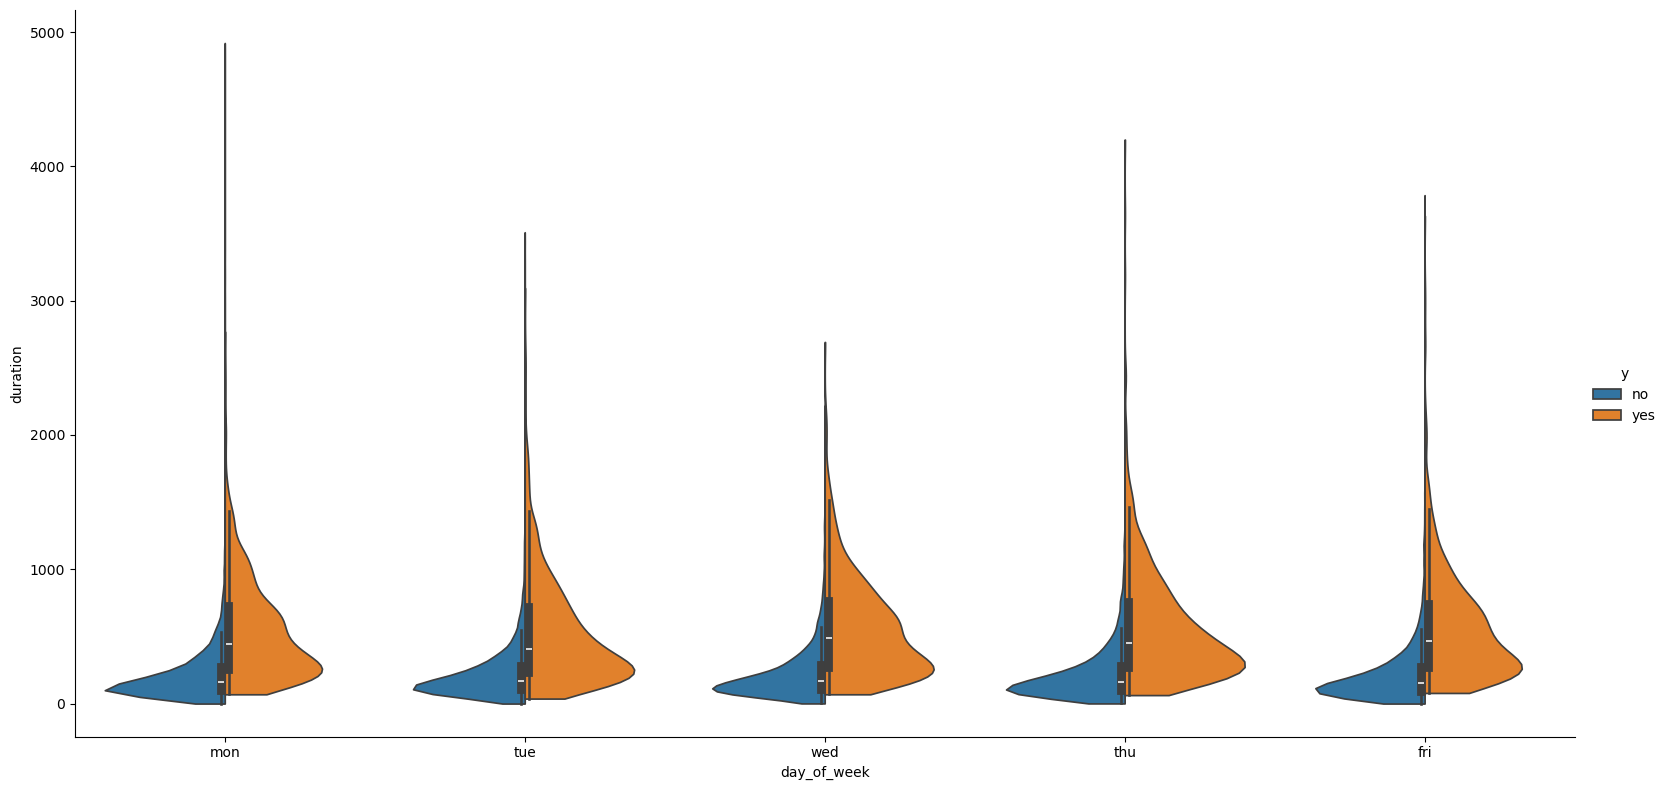

In [43]:
g = sns.catplot(
    data=tele_df, x='day_of_week', y='duration',
    hue='y', scale='count', kind='violin',
    split=True, legend_out=True, height=8, aspect=2, cut=0, 
    order=['mon','tue','wed','thu','fri']
);

### **Dimension : Marital Status**

univariate_analysis_categorical_var(tele_df, 'marital', 'Marital Status')

### **Dimension : Education**

univariate_analysis_categorical_var(tele_df, 'education', 'Education')

# Create a cross-tabulation (counts of combinations)
heatmap_data = pd.crosstab(tele_df["education"], tele_df["year"])

# Plot heatmap
plt.figure(figsize=(6,4))
ax = sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d")
colorbar = ax.collections[0].colorbar #.ax.set_yticklabels([])
colorbar.set_ticks([]) # remove tick marks
colorbar.set_ticklabels([]) # remove tick labels
plt.title("Heatmap of Education vs Year")
plt.show()


sns.heatmap(tele_df.groupby(['months_order', 'year'])['y_binary'].mean().unstack().round(2), annot=True, cmap='Blues')

sns.heatmap(tele_df.groupby(['months_order', 'year'])['y_binary'].count().unstack(), annot=True,fmt='.0f', cmap='Blues')

### **Dimension : Default**


univariate_analysis_categorical_var(tele_df, 'default', 'Default')